<h1>SPTech — Análise de Dados</h1>
<h1>EDA — Análise Exploratória de Dados</h1>

Este notebook executa um roteiro completo de EDA sobre **qualquer base tabular**.

Para usar na base do seu Projeto de Inovação, altere **apenas a célula de configuração** logo abaixo e execute tudo (`Executar tudo` / `Run all`). Nenhuma outra célula precisa ser editada.

O roteiro segue a ordem apresentada na Aula 6:

| Seção | Conteúdo |
| --- | --- |
| 0 | Configuração e carga |
| 1 | Estrutura, grão e chave |
| 2 | Qualidade: nulos, nulos disfarçados, duplicatas |
| 3 | Univariada numérica: centro, dispersão, forma, extremos |
| 4 | Univariada categórica: frequência, cardinalidade, cauda longa |
| 5 | Outliers: IQR, z-score e z-score modificado |
| 6 | Séries temporais: tendência, sazonalidade, quebras |
| 7 | Bivariada: o gráfico certo para cada par de tipos |
| 8 | Correlação: Pearson, Spearman e o alerta de Anscombe |
| 9 | Segmentação com o n ao lado |
| 10 | Multivariada: facetas, confundimento e teste de Simpson |
| 11 | Síntese: achados, hipóteses e decisões |

---

# 0) Configuração

**Esta é a única célula que você precisa alterar.**

Preencha o caminho do arquivo e, se quiser, indique as colunas que têm papel especial. Tudo o que ficar vazio é detectado automaticamente.

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO — altere apenas esta célula
# ═══════════════════════════════════════════════════════════════════

CAMINHO  = "../data/base_eda_internacional.csv"
SEP      = ";"
ENCODING = "latin1"
DECIMAL  = "."

COLS_DATA    = ["dh_partida_real"]
COL_ALVO     = "nr_passag_pagos"
COLS_IGNORAR = ["id_combinada", "sg_empresa_icao", "nr_voo",
                "sg_icao_origem", "sg_icao_destino",
                "nr_etapa", "nr_escala_destino"]
GRAO         = ["sg_empresa_icao", "nr_voo", "dh_partida_real",
                "sg_icao_origem", "sg_icao_destino", "nr_escala_destino",
                "ds_cotran"]
# Valores que devem ser lidos como ausentes
NA_EXTRA = ["", "-", "--", "N/A", "NA", "n/a", "não informado",
            "nao informado", "sem dado", "null", "NULL", "?", "#N/D"]

# Ajustes de exibição
MAX_CATEGORIAS  = 15      # categorias mostradas nos gráficos de barras
MIN_N_SEGMENTO  = 30      # n mínimo para um segmento ser considerado confiável
# ═══════════════════════════════════════════════════════════════════

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12

print("Bibliotecas carregadas. Pandas", pd.__version__)

Bibliotecas carregadas. Pandas 3.0.6


## 0.1) Carga

A leitura é feita **com tudo como texto**, como vimos na Aula 5: a conversão de tipos é decisão nossa, não palpite da biblioteca. A conversão acontece na célula seguinte, e o que não converter fica registrado.

In [3]:
df_bruto = pd.read_csv(
    CAMINHO,
    sep=SEP,
    encoding=ENCODING,
    dtype=str,
    na_values=NA_EXTRA,
    keep_default_na=True,
)

print(f"Arquivo: {CAMINHO}")
print(f"Linhas: {df_bruto.shape[0]:,}   Colunas: {df_bruto.shape[1]}".replace(",", "."))
df_bruto.head()

Arquivo: ../data/base_eda_internacional.csv
Linhas: 214.882   Colunas: 27


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
0,95767917,IBE,0272,29/01/2025 20:46:00,SBGR,LEMD,NaN,1,2,320,3,0,15500,0,0,0,IBÉRIA LINEAS AEREAS DE ESPAÑA SOCIEDAD ANONIM...,ESPANHA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO
1,95767929,IBE,0268,19/01/2025 15:48:00,SBGR,LEMD,NaN,1,2,284,4,0,4720,0,0,355,IBÉRIA LINEAS AEREAS DE ESPAÑA SOCIEDAD ANONIM...,ESPANHA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO
2,95767934,IBE,0268,24/01/2025 16:56:00,SBGR,LEMD,NaN,1,2,263,2,0,8785,0,0,563,IBÉRIA LINEAS AEREAS DE ESPAÑA SOCIEDAD ANONIM...,ESPANHA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO
3,95767936,IBE,0268,25/01/2025 15:41:00,SBGR,LEMD,NaN,1,2,268,3,0,1375,0,0,591,IBÉRIA LINEAS AEREAS DE ESPAÑA SOCIEDAD ANONIM...,ESPANHA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO
4,95767938,IBE,0268,26/01/2025 15:20:00,SBGR,LEMD,NaN,1,2,276,4,0,2705,0,0,415,IBÉRIA LINEAS AEREAS DE ESPAÑA SOCIEDAD ANONIM...,ESPANHA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO


## 0.2) Conversão de tipos

Cada coluna é testada: se a maior parte dos valores válidos converte para número, ela vira numérica; se converte para data, vira datetime; caso contrário permanece como texto.

O relatório mostra **quanto se perdeu** em cada conversão. Perda alta é sinal de que a coluna precisa de limpeza antes, não de conversão.

In [4]:
import re

def tenta_numero(serie, decimal=DECIMAL):
    """Converte para número tratando separador decimal e de milhar.

    O separador de milhar só é removido quando está em posição de milhar
    (seguido de exatamente três dígitos). Isso evita que "999.0" vire 9990
    numa base configurada com decimal vírgula.
    """
    s = serie.astype(str).str.strip()
    if decimal == ",":
        s = s.str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)
        s = s.str.replace(",", ".", regex=False)
    else:
        s = s.str.replace(r",(?=\d{3}(\D|$))", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def tenta_data(serie):
    return pd.to_datetime(serie, errors="coerce", dayfirst=True)


df = df_bruto.copy()
relatorio_conversao = []

for col in df.columns:
    validos = df[col].notna().sum()
    if validos == 0:
        relatorio_conversao.append([col, "vazia", 0, 0.0])
        continue

    if col in COLS_DATA:
        conv = tenta_data(df[col])
        df[col] = conv
        perda = (df_bruto[col].notna() & conv.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    num = tenta_numero(df[col])
    taxa_num = num.notna().sum() / validos

    if taxa_num >= 0.90:
        df[col] = num
        perda = (df_bruto[col].notna() & num.isna()).sum()
        relatorio_conversao.append([col, "numérica", validos, round(perda / validos * 100, 1)])
        continue

    dat = tenta_data(df[col])
    if dat.notna().sum() / validos >= 0.90:
        df[col] = dat
        perda = (df_bruto[col].notna() & dat.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    relatorio_conversao.append([col, "texto", validos, 0.0])

rel_conv = pd.DataFrame(relatorio_conversao,
                        columns=["coluna", "tipo_final", "validos", "perda_pct"])
rel_conv.sort_values("perda_pct", ascending=False).head(20)

,coluna,tipo_final,validos,perda_pct
0,id_combinada,numérica,214882,0.0
1,sg_empresa_icao,texto,214882,0.0
2,nr_voo,numérica,214882,0.0
3,dh_partida_real,datetime,214882,0.0
4,sg_icao_origem,texto,214882,0.0
5,sg_icao_destino,texto,214882,0.0
6,ds_cotran,texto,114795,0.0
7,nr_etapa,numérica,214882,0.0
8,nr_escala_destino,numérica,214882,0.0
9,nr_passag_pagos,numérica,214814,0.0


→ **Leia a coluna perda_pct.** Valor acima de 1% significa que parte dos dados não converteu e virou nulo. Antes de seguir, investigue: é sujeira pontual ou é a coluna inteira em outro formato?

In [5]:
# Classificação das colunas por papel na análise
COLS_NUM = [c for c in df.select_dtypes(include="number").columns
            if c not in COLS_IGNORAR]
COLS_CAT = [c for c in df.select_dtypes(include=["object", "category"]).columns
            if c not in COLS_IGNORAR]
COLS_DT  = list(df.select_dtypes(include="datetime").columns)

# Identificadores disfarçados de número.
# Critério: quase todos os valores distintos E sem casas decimais.
# Variável contínua legítima (valor, peso, tempo) tem decimais e escapa daqui.
PADRAO_ID = ("id", "cod", "cpf", "cnpj", "cep", "matric", "protocolo",
             "registro", "numero", "num_", "_ra", "chave")

def parece_identificador(serie, nome):
    s = serie.dropna()
    if s.empty:
        return False
    quase_unico = s.nunique() > 0.95 * len(s)
    inteiro = (s % 1 == 0).all()
    nome_sugere = any(p in nome.lower() for p in PADRAO_ID)
    return quase_unico and (inteiro or nome_sugere)

possiveis_id = [c for c in COLS_NUM if parece_identificador(df[c], c)]
COLS_NUM = [c for c in COLS_NUM if c not in possiveis_id]

print(f"Numéricas   ({len(COLS_NUM)}): {COLS_NUM}")
print()
print(f"Categóricas ({len(COLS_CAT)}): {COLS_CAT}")
print()
print(f"Datas       ({len(COLS_DT)}): {COLS_DT}")
print()
if possiveis_id:
    print(f"Excluídas por parecerem identificadores: {possiveis_id}")

Numéricas   (7): ['nr_passag_pagos', 'nr_passag_gratis', 'kg_bagagem_livre', 'kg_carga_paga', 'kg_bagagem_excesso', 'kg_carga_gratis', 'kg_correio']

Categóricas (12): ['ds_cotran', 'nm_empresa', 'nm_pais_empresa', 'ds_tipo_empresa', 'ds_grupo_di', 'ds_servico_tipo_linha', 'nm_municipio_origem', 'sg_uf_origem', 'nm_municipio_destino', 'nm_pais_destino', 'nm_continente_destino', 'grupo_destino']

Datas       (1): ['dh_partida_real']



---
# 1) Estrutura, grão e chave

A pergunta da Aula 5 que abre toda EDA: **o que representa uma linha desta tabela?**

In [6]:
print("=" * 60)
print("ESTRUTURA DA BASE")
print("=" * 60)
print(f"Linhas:   {df.shape[0]:,}".replace(",", "."))
print(f"Colunas:  {df.shape[1]}")
print(f"Memória:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

ESTRUTURA DA BASE
Linhas:   214.882
Colunas:  27


Memória:  268.69 MB

<class 'pandas.DataFrame'>
RangeIndex: 214882 entries, 0 to 214881
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id_combinada           214882 non-null  int64         
 1   sg_empresa_icao        214882 non-null  str           
 2   nr_voo                 214882 non-null  int64         
 3   dh_partida_real        214882 non-null  datetime64[us]
 4   sg_icao_origem         214882 non-null  str           
 5   sg_icao_destino        214882 non-null  str           
 6   ds_cotran              114795 non-null  str           
 7   nr_etapa               214882 non-null  int64         
 8   nr_escala_destino      214882 non-null  int64         
 9   nr_passag_pagos        214814 non-null  float64       
 10  nr_passag_gratis       214814 non-null  float64       
 11  kg_bagagem_livre       214814 non-null  float64       
 12  kg_carga_paga          214814 non-

In [7]:
# Verificação do grão declarado na configuração
if GRAO:
    dup = df.duplicated(subset=GRAO).sum()
    print(f"Grão declarado: {GRAO}")
    print(f"Linhas duplicadas nesse grão: {dup}")
    if dup == 0:
        print("OK — a chave declarada identifica unicamente cada linha.")
    else:
        print("ATENÇÃO — a chave declarada NÃO é única. O grão real é mais fino.")
else:
    print("Nenhum grão declarado em GRAO.")
    print("Candidatos a chave única (colunas sem valores repetidos):")
    print()
    for col in df.columns:
        if df[col].notna().all() and df[col].nunique() == len(df):
            print(f"   {col}")

Grão declarado: ['sg_empresa_icao', 'nr_voo', 'dh_partida_real', 'sg_icao_origem', 'sg_icao_destino', 'nr_escala_destino', 'ds_cotran']
Linhas duplicadas nesse grão: 6
ATENÇÃO — a chave declarada NÃO é única. O grão real é mais fino.


---
# 2) Qualidade: nulos, disfarçados e duplicatas

In [8]:
def relatorio_qualidade(df):
    rel = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(1),
        "distintos": df.nunique(dropna=True),
        "pct_distintos": (df.nunique(dropna=True) / len(df) * 100).round(1),
    })
    return rel.sort_values("pct_nulos", ascending=False)


qualidade = relatorio_qualidade(df)
qualidade

,tipo,nulos,pct_nulos,distintos,pct_distintos
ds_cotran,str,100087,46.6,3,0.0
sg_empresa_icao,str,0,0.0,114,0.1
id_combinada,int64,0,0.0,214882,100.0
nr_voo,int64,0,0.0,1922,0.9
dh_partida_real,datetime64[us],0,0.0,121799,56.7
sg_icao_origem,str,0,0.0,32,0.0
sg_icao_destino,str,0,0.0,195,0.1
nr_etapa,int64,0,0.0,7,0.0
nr_escala_destino,int64,0,0.0,8,0.0
nr_passag_pagos,float64,68,0.0,485,0.2


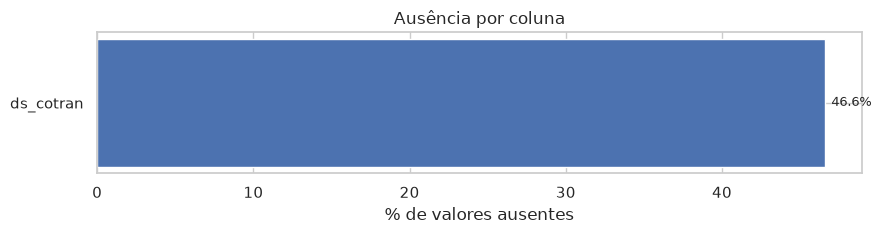

In [9]:
# Gráfico dos nulos por coluna
com_nulos = qualidade[qualidade["pct_nulos"] > 0]

if len(com_nulos):
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(com_nulos))))
    ax.barh(com_nulos.index[::-1], com_nulos["pct_nulos"][::-1])
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Ausência por coluna")
    for i, v in enumerate(com_nulos["pct_nulos"][::-1]):
        ax.text(v + 0.4, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2.1) O mapa da ausência

Cada linha do gráfico é uma linha da base; cada coluna, uma coluna. As marcas escuras são valores ausentes.

**O que procurar:** faixas horizontais contínuas. Ausência em bloco nunca é acaso — é troca de sistema, mudança de formulário ou falha de carga em um período.

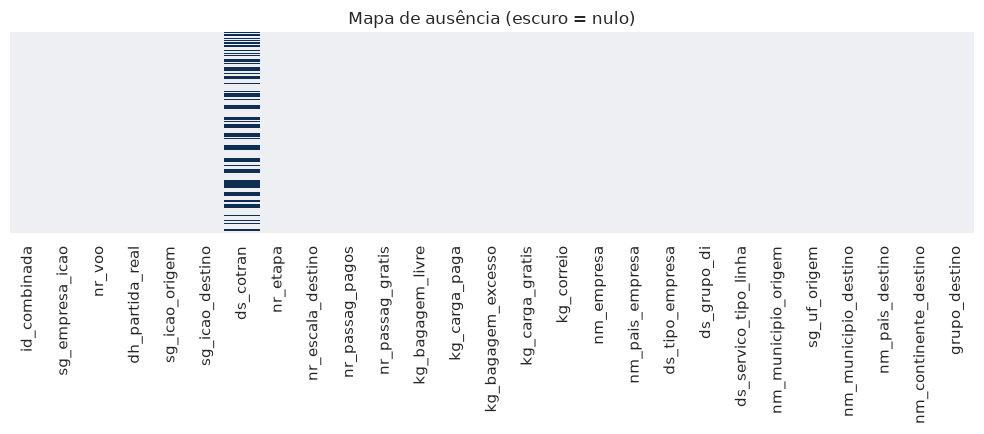

In [10]:
if df.isna().any().any():
    amostra = df if len(df) <= 500 else df.sample(500, random_state=42).sort_index()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(amostra.isna(), cbar=False, yticklabels=False,
                cmap=["#EDEFF2", "#0F2E54"], ax=ax)
    ax.set_title("Mapa de ausência (escuro = nulo)")
    plt.tight_layout()
    plt.show()
else:
    print("Base sem valores ausentes — nada a mapear.")

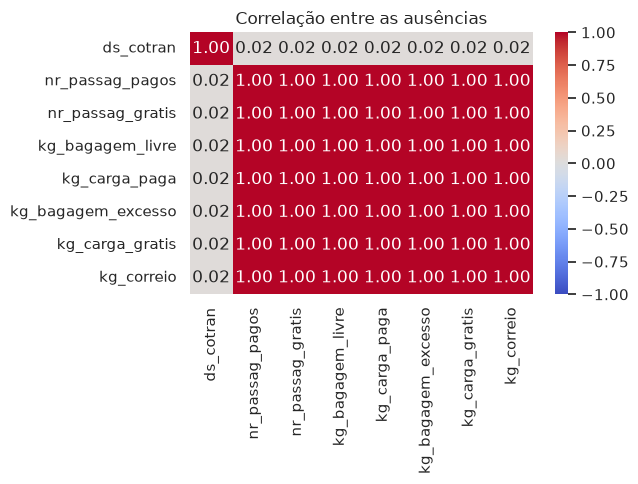

Valores próximos de 1 indicam colunas que faltam sempre juntas —
sinal de que vêm da mesma origem, que falhou.


In [11]:
# Colunas que costumam faltar juntas
nulos_bin = df.isna()
nulos_bin = nulos_bin.loc[:, nulos_bin.any()]

if nulos_bin.shape[1] >= 2:
    co = nulos_bin.corr()
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(co, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlação entre as ausências")
    plt.tight_layout()
    plt.show()
    print("Valores próximos de 1 indicam colunas que faltam sempre juntas —")
    print("sinal de que vêm da mesma origem, que falhou.")
else:
    print("Menos de duas colunas com ausência — correlação não se aplica.")

## 2.2) Nulos disfarçados

O `isna()` só enxerga o que foi reconhecido como ausente na leitura. O resto está disfarçado de valor.

In [12]:
SUSPEITOS_TEXTO = {"", " ", "-", "--", "n/a", "na", "nao informado",
                   "não informado", "sem dado", "null", "none", "nan",
                   "?", "xx", "zzz", "000", "999", "9999", "sem informacao"}

achados = []
for col in COLS_CAT:
    s = df[col].astype(str).str.strip().str.lower()
    n = s.isin(SUSPEITOS_TEXTO).sum()
    if n:
        exemplos = s[s.isin(SUSPEITOS_TEXTO)].value_counts().head(3).to_dict()
        achados.append([col, n, round(n / len(df) * 100, 1), str(exemplos)])

if achados:
    print("NULOS DISFARÇADOS EM COLUNAS DE TEXTO")
    display(pd.DataFrame(achados, columns=["coluna", "qtd", "pct", "exemplos"]))
else:
    print("Nenhum valor de texto suspeito encontrado.")

Nenhum valor de texto suspeito encontrado.


In [13]:
# Sentinelas numéricas: valores repetidos em excesso nos extremos
SENTINELAS = [-1, 0, 99, 999, 9999, 99999, 999999, 99999999]

achados_num = []
for col in COLS_NUM:
    s = df[col].dropna()
    if s.empty:
        continue
    for v in SENTINELAS:
        n = (s == v).sum()
        if n and n / len(s) > 0.01:
            achados_num.append([col, v, n, round(n / len(s) * 100, 1)])

if achados_num:
    print("CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)")
    display(pd.DataFrame(achados_num, columns=["coluna", "valor", "qtd", "pct"]))
    print()
    print("Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.")
else:
    print("Nenhuma sentinela numérica evidente.")

print()
print("Mínimos e máximos — o extremo costuma denunciar:")
if COLS_NUM:
    display(df[COLS_NUM].describe().T[["min", "max"]])

CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)


,coluna,valor,qtd,pct
0,nr_passag_pagos,0,67462,31.4
1,nr_passag_gratis,0,153489,71.5
2,kg_bagagem_livre,0,154727,72.0
3,kg_carga_paga,0,142997,66.6
4,kg_bagagem_excesso,0,207039,96.4
5,kg_carga_gratis,0,205917,95.9
6,kg_correio,0,208657,97.1



Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.

Mínimos e máximos — o extremo costuma denunciar:


,min,max
nr_passag_pagos,0.0,484.0
nr_passag_gratis,0.0,260.0
kg_bagagem_livre,0.0,9343.0
kg_carga_paga,0.0,126977.0
kg_bagagem_excesso,0.0,1279.0
kg_carga_gratis,-33.0,43554.0
kg_correio,0.0,8079.0


In [14]:
# Duplicatas
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")
if GRAO:
    print(f"Duplicadas no grão {GRAO}: {df.duplicated(subset=GRAO).sum()}")

if df.duplicated().sum():
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Linhas totalmente duplicadas: 0
Duplicadas no grão ['sg_empresa_icao', 'nr_voo', 'dh_partida_real', 'sg_icao_origem', 'sg_icao_destino', 'nr_escala_destino', 'ds_cotran']: 6


## 2.3) [Grupo 4] As linhas que repetem a chave do grão

Células acrescentadas pelo grupo. A chave declarada na configuração inclui `nr_escala_destino`, porque o mesmo par de aeroportos de um voo pode aparecer com escalas de destino diferentes. O que ainda se repete está listado abaixo.

In [15]:
# [Grupo 4] As linhas que repetem a chave do grão
dup = df[df.duplicated(subset=GRAO, keep=False)].sort_values(GRAO)
print(f"Linhas envolvidas: {len(dup)} ({df.duplicated(subset=GRAO).sum()} repetições)")
display(dup[GRAO + ["id_combinada", "ds_grupo_di", "nr_passag_pagos", "kg_carga_paga"]])

Linhas envolvidas: 12 (6 repetições)


,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,nr_escala_destino,ds_cotran,id_combinada,ds_grupo_di,nr_passag_pagos,kg_carga_paga
76837,ARG,1249,2025-08-01 00:20:00,SBGR,SABE,2,NaN,98357766,NÃO REGULAR,152.0,0.0
89033,ARG,1249,2025-08-01 00:20:00,SBGR,SABE,2,NaN,98819921,REGULAR,152.0,0.0
122262,DWI,6001,2025-12-31 23:48:00,SBGR,MDPC,2,NaN,104206043,NÃO REGULAR,180.0,0.0
147345,DWI,6001,2025-12-31 23:48:00,SBGR,MDPC,2,NaN,103030591,REGULAR,180.0,0.0
162439,GTI,8050,2026-04-01 10:32:00,SBGR,SEQM,3,NaN,104241755,REGULAR,0.0,21404.0
173252,GTI,8050,2026-04-01 10:32:00,SBGR,SEQM,3,NaN,105139352,NÃO REGULAR,0.0,21404.0
138317,GTI,8052,2026-02-01 16:49:00,SBGR,SCEL,3,NaN,102540639,NÃO REGULAR,0.0,109079.0
150172,GTI,8052,2026-02-01 16:49:00,SBGR,SCEL,3,NaN,103334200,REGULAR,0.0,109079.0
150143,GTI,8052,2026-03-01 09:56:00,SBGR,SCEL,3,NaN,103333796,NÃO REGULAR,0.0,81712.0
160005,GTI,8052,2026-03-01 09:56:00,SBGR,SCEL,3,NaN,104241763,REGULAR,0.0,81712.0


## 2.4) [Grupo 4] O padrão das ausências

O relatório de qualidade mostra duas ausências: `ds_cotran` (46,6%) e as sete medidas numéricas (68 linhas). As células abaixo comparam as linhas com e sem o valor para descobrir de onde vem cada uma.

% de ds_cotran nulo por tipo de empresa


,registros,pct_nulo
ds_tipo_empresa,,
ESTRANGEIRA NÃO REGULAR,826,100.0
ESTRANGEIRA REGULAR,99261,100.0
TRANSPORTE AÉREO NÃO REGULAR,33,0.0
"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",57204,0.0
TRANSPORTE AÉREO REGULAR,57558,0.0



ds_cotran x ds_servico_tipo_linha (contagem)


ds_cotran,CONEXÃO DOMÉSTICO,CONEXÃO INTERNACIONAL,DESEMBARQUE,NULO
ds_servico_tipo_linha,,,,
CARGUEIRO,2405,2405,2555,0
NÃO IDENTIFICADO,0,0,0,100087
PASSAGEIRO,34043,34666,38721,0


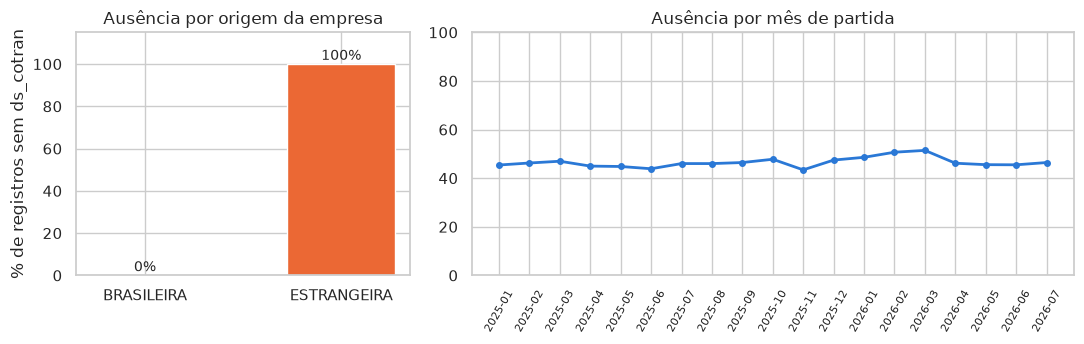

Faixa mensal do % de nulos: 43.4% a 51.4%


In [16]:
# [Grupo 4] Comparação entre os registros com e sem ds_cotran
origem_empresa = pd.Series(
    np.where(df["ds_tipo_empresa"].str.startswith("ESTRANGEIRA"), "ESTRANGEIRA", "BRASILEIRA"),
    index=df.index, name="origem_empresa")
cotran_nulo = df["ds_cotran"].isna()

print("% de ds_cotran nulo por tipo de empresa")
display(pd.DataFrame({"registros": df.groupby("ds_tipo_empresa").size(),
                      "pct_nulo": (cotran_nulo.groupby(df["ds_tipo_empresa"]).mean() * 100).round(1)}))
print("\nds_cotran x ds_servico_tipo_linha (contagem)")
display(pd.crosstab(df["ds_servico_tipo_linha"], df["ds_cotran"].fillna("NULO")))

mes_partida = df["dh_partida_real"].dt.to_period("M")
pct_mes = (cotran_nulo.groupby(mes_partida).mean() * 100)
pct_mes = pct_mes[(pct_mes.index >= "2025-01") & (pct_mes.index <= "2026-07")]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1, 1.8]})
pct_org = cotran_nulo.groupby(origem_empresa).mean() * 100
axes[0].bar(pct_org.index, pct_org.values, color=["#2a78d6", "#eb6834"], width=0.55)
for i, v in enumerate(pct_org.values):
    axes[0].text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=10)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("% de registros sem ds_cotran")
axes[0].set_title("Ausência por origem da empresa")
axes[1].plot(pct_mes.index.astype(str), pct_mes.values, color="#2a78d6", lw=2, marker="o", ms=4)
axes[1].set_ylim(0, 100)
axes[1].set_title("Ausência por mês de partida")
axes[1].tick_params(axis="x", rotation=60, labelsize=8)
plt.tight_layout()
plt.show()
print(f"Faixa mensal do % de nulos: {pct_mes.min():.1f}% a {pct_mes.max():.1f}%")

In [17]:
# [Grupo 4] Os 68 registros sem nenhuma medida numérica
sem_medida = df[COLS_NUM].isna().all(axis=1)
print(f"Registros sem nenhuma medida: {sem_medida.sum()} ({sem_medida.mean() * 100:.2f}%)")
print(f"Nulos numéricos fora desse grupo: {df.loc[~sem_medida, COLS_NUM].isna().sum().sum()}")
print("\nPerfil (com medida x sem medida), % das linhas de cada grupo:")
for col, serie in [("origem da empresa", origem_empresa), ("ds_grupo_di", df["ds_grupo_di"]),
                   ("ds_servico_tipo_linha", df["ds_servico_tipo_linha"])]:
    tab = pd.crosstab(serie, sem_medida.map({True: "sem medida", False: "com medida"}), normalize="columns") * 100
    print(f"\n{col}")
    display(tab.round(1))
print("\nSem medida por mês de partida:")
display(df.loc[sem_medida, "dh_partida_real"].dt.to_period("M").value_counts().sort_index().to_frame("registros").T)

Registros sem nenhuma medida: 68 (0.03%)
Nulos numéricos fora desse grupo: 0

Perfil (com medida x sem medida), % das linhas de cada grupo:

origem da empresa


col_0,com medida,sem medida
origem_empresa,,
BRASILEIRA,53.4,0.0
ESTRANGEIRA,46.6,100.0



ds_grupo_di


col_0,com medida,sem medida
ds_grupo_di,,
IMPRODUTIVO,0.7,35.3
NÃO REGULAR,6.5,19.1
REGULAR,92.9,45.6



ds_servico_tipo_linha


col_0,com medida,sem medida
ds_servico_tipo_linha,,
CARGUEIRO,3.4,0.0
NÃO IDENTIFICADO,46.6,100.0
PASSAGEIRO,50.0,0.0



Sem medida por mês de partida:


dh_partida_real,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-11,2025-12,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
registros,4,2,4,6,2,2,1,3,2,2,4,3,4,3,7,9,10


---
# 3) Univariada numérica

Centro, dispersão, forma e extremos — para cada variável numérica, de uma vez.

In [18]:
def descritiva_completa(df, cols):
    linhas = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        media, dp = s.mean(), s.std()
        linhas.append({
            "variavel": c,
            "n": len(s),
            "nulos_pct": round(df[c].isna().mean() * 100, 1),
            "media": round(media, 2),
            "mediana": round(s.median(), 2),
            "desvio": round(dp, 2),
            "cv_pct": round(dp / media * 100, 1) if media else np.nan,
            "min": round(s.min(), 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "max": round(s.max(), 2),
            "iqr": round(q3 - q1, 2),
            "assimetria": round(s.skew(), 2),
            "curtose": round(s.kurtosis(), 2),
        })
    return pd.DataFrame(linhas).set_index("variavel")


if COLS_NUM:
    desc = descritiva_completa(df, COLS_NUM)
    display(desc)
else:
    print("Nenhuma coluna numérica identificada.")

,n,nulos_pct,media,mediana,desvio,cv_pct,min,q1,q3,max,iqr,assimetria,curtose
variavel,,,,,,,,,,,,,
nr_passag_pagos,214814,0.0,107.94,114.0,103.39,95.8,0.0,0.0,170.0,484.0,170.0,0.52,-0.73
nr_passag_gratis,214814,0.0,1.36,0.0,3.29,242.6,0.0,0.0,1.0,260.0,1.0,6.53,226.14
kg_bagagem_livre,214814,0.0,433.64,0.0,1009.13,232.7,0.0,0.0,85.0,9343.0,85.0,2.93,9.17
kg_carga_paga,214814,0.0,2935.32,0.0,8432.15,287.3,0.0,0.0,900.0,126977.0,900.0,5.81,47.30
kg_bagagem_excesso,214814,0.0,1.11,0.0,13.98,1255.1,0.0,0.0,0.0,1279.0,0.0,26.03,1082.58
kg_carga_gratis,214814,0.0,12.56,0.0,179.54,1429.3,-33.0,0.0,0.0,43554.0,0.0,88.72,17325.49
kg_correio,214814,0.0,12.98,0.0,149.29,1150.1,0.0,0.0,0.0,8079.0,0.0,21.37,599.63


## 3.1) Leitura automática da forma

A regra aplicada abaixo é a da Aula 6: assimetria acima de 1 em módulo já pede mediana em vez de média.

In [19]:
if COLS_NUM:
    for c in desc.index:
        a = desc.loc[c, "assimetria"]
        k = desc.loc[c, "curtose"]
        cv = desc.loc[c, "cv_pct"]

        if abs(a) < 0.5:
            forma = "aproximadamente simétrica — a média representa bem"
        elif abs(a) < 1:
            forma = "levemente assimétrica — média e mediana ainda próximas"
        else:
            lado = "à direita" if a > 0 else "à esquerda"
            forma = f"FORTEMENTE assimétrica {lado} — use a mediana"

        cauda = " Caudas pesadas: extremos mais frequentes que o esperado." if k > 3 else ""
        disp = " Dispersão muito alta." if pd.notna(cv) and cv > 100 else ""

        print(f"{c}")
        print(f"   assimetria {a:+.2f} | curtose {k:+.2f} -> {forma}.{cauda}{disp}")
        print()

nr_passag_pagos
   assimetria +0.52 | curtose -0.73 -> levemente assimétrica — média e mediana ainda próximas.

nr_passag_gratis
   assimetria +6.53 | curtose +226.14 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_bagagem_livre
   assimetria +2.93 | curtose +9.17 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_carga_paga
   assimetria +5.81 | curtose +47.30 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_bagagem_excesso
   assimetria +26.03 | curtose +1082.58 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mais frequentes que o esperado. Dispersão muito alta.

kg_carga_gratis
   assimetria +88.72 | curtose +17325.49 -> FORTEMENTE assimétrica à direita — use a mediana. Caudas pesadas: extremos mai

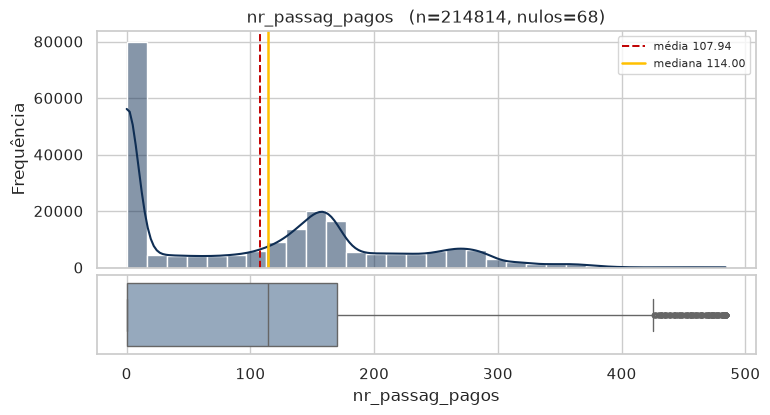

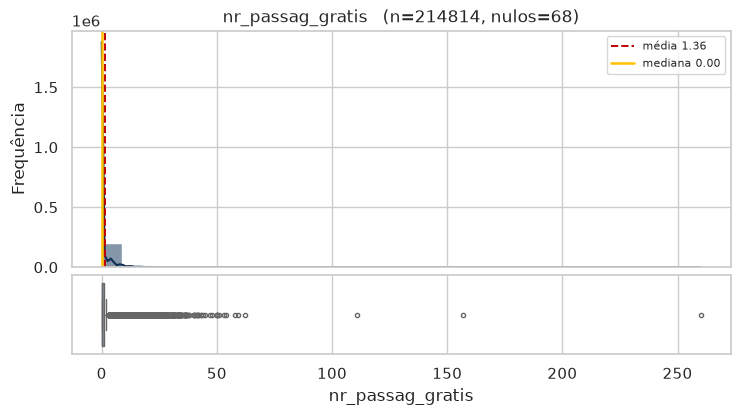

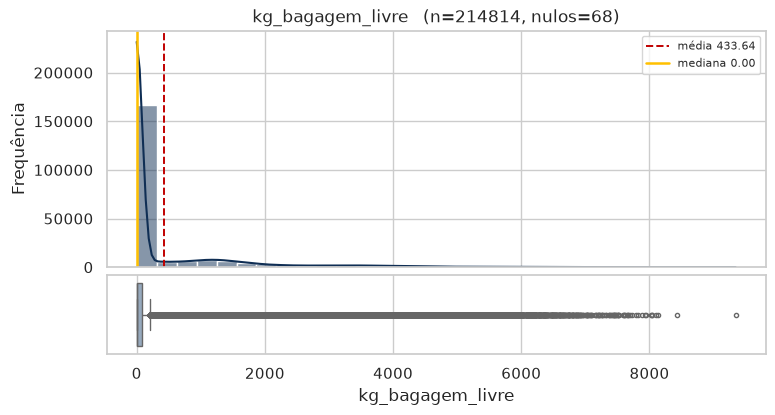

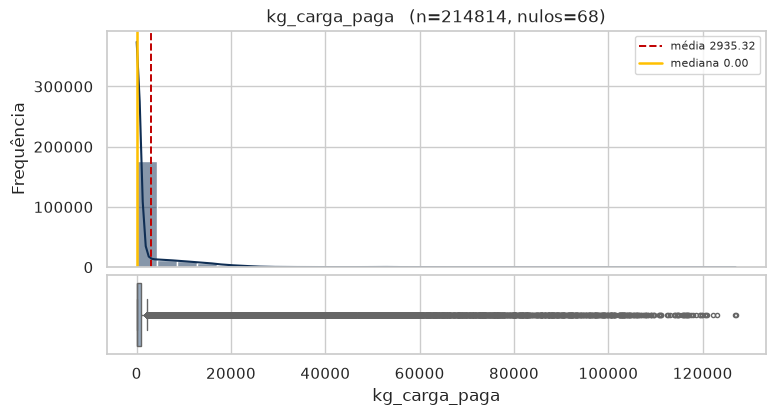

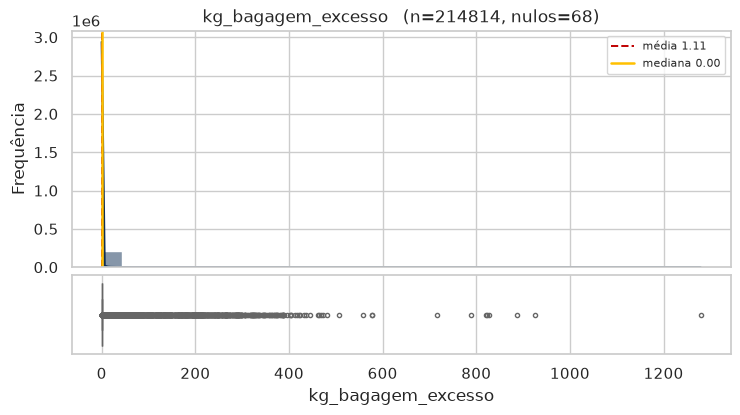

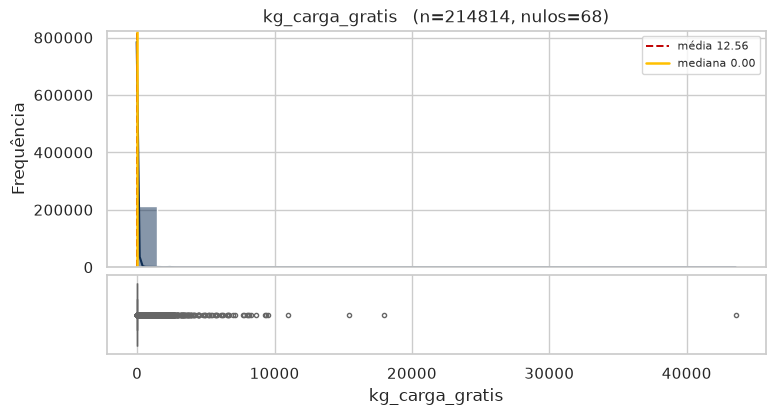

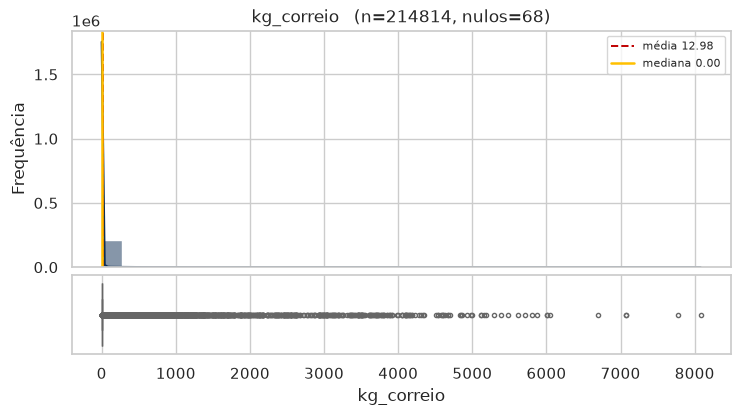

In [20]:
# Histograma + boxplot para cada variável numérica
for c in COLS_NUM:
    s = df[c].dropna()
    if s.empty or s.nunique() < 2:
        continue

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(8.5, 4.2),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    sns.histplot(s, bins=min(30, max(10, s.nunique())), kde=True, ax=ax1,
                 color="#0F2E54")
    ax1.axvline(s.mean(), color="#C00000", ls="--", lw=1.4, label=f"média {s.mean():.2f}")
    ax1.axvline(s.median(), color="#FFC000", ls="-", lw=1.8, label=f"mediana {s.median():.2f}")
    ax1.legend(fontsize=8)
    ax1.set_ylabel("Frequência")
    ax1.set_title(f"{c}   (n={len(s)}, nulos={df[c].isna().sum()})")

    sns.boxplot(x=s, ax=ax2, color="#8FA9C4", fliersize=3)
    ax2.set_xlabel(c)
    plt.tight_layout()
    plt.show()

→ **Onde média e mediana se afastam muito**, a distribuição é assimétrica e a média está sendo puxada por extremos. Reporte a mediana.

→ **Se o histograma tem dois picos**, o boxplot vai escondê-los. Sempre olhe os dois.

---
# 4) Univariada categórica

In [21]:
if COLS_CAT:
    card = pd.DataFrame({
        "distintos": df[COLS_CAT].nunique(dropna=True),
        "nulos_pct": (df[COLS_CAT].isna().mean() * 100).round(1),
        "mais_frequente": [df[c].mode().iloc[0] if not df[c].mode().empty else None
                           for c in COLS_CAT],
        "freq_do_top_pct": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1)
                            if df[c].notna().any() else np.nan for c in COLS_CAT],
    }).sort_values("distintos", ascending=False)

    card["leitura"] = np.select(
        [card["distintos"] <= 10, card["distintos"] <= 30, card["distintos"] <= 100],
        ["barras simples", "barras horizontais ordenadas", "top N + Outros"],
        default="cardinalidade muito alta: identificador ou texto livre?")
    display(card)
else:
    print("Nenhuma coluna categórica identificada.")

,distintos,nulos_pct,mais_frequente,freq_do_top_pct,leitura
nm_municipio_destino,191,0.0,BUENOS AIRES,15.0,cardinalidade muito alta: identificador ou tex...
nm_empresa,114,0.0,TAM LINHAS AÉREAS S.A.,26.8,cardinalidade muito alta: identificador ou tex...
nm_pais_destino,74,0.0,ARGENTINA,26.2,top N + Outros
nm_pais_empresa,46,0.0,BRASIL,53.4,top N + Outros
nm_municipio_origem,32,0.0,GUARULHOS,53.4,top N + Outros
sg_uf_origem,23,0.0,SP,61.3,barras horizontais ordenadas
nm_continente_destino,7,0.0,AMÉRICA DO SUL,57.1,barras simples
ds_tipo_empresa,5,0.0,ESTRANGEIRA REGULAR,46.2,barras simples
ds_cotran,3,46.6,DESEMBARQUE,36.0,barras simples
ds_servico_tipo_linha,3,0.0,PASSAGEIRO,50.0,barras simples


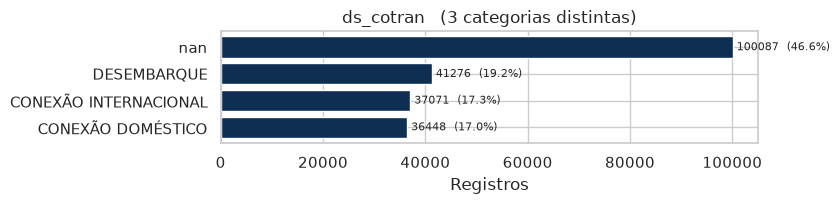

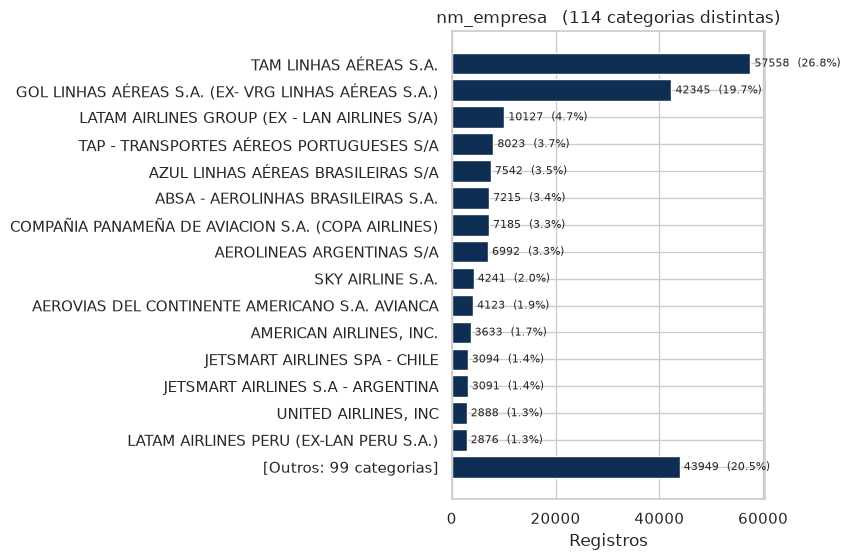

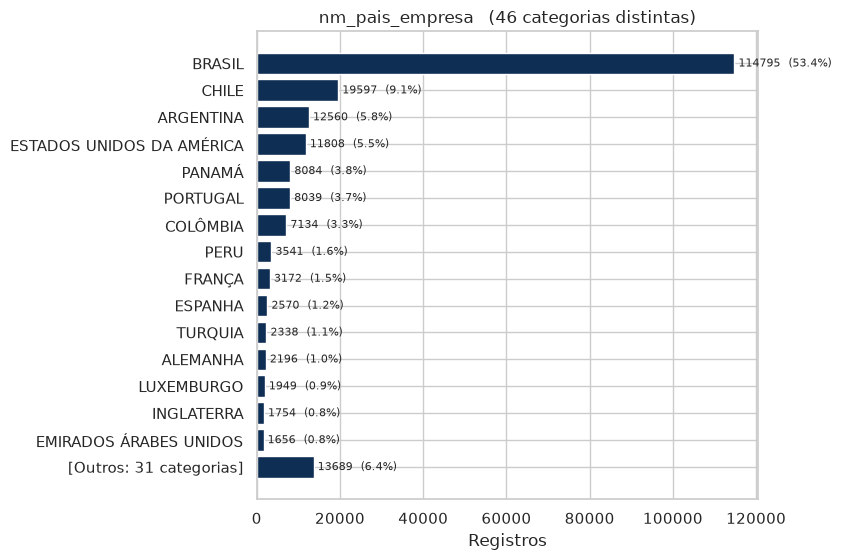

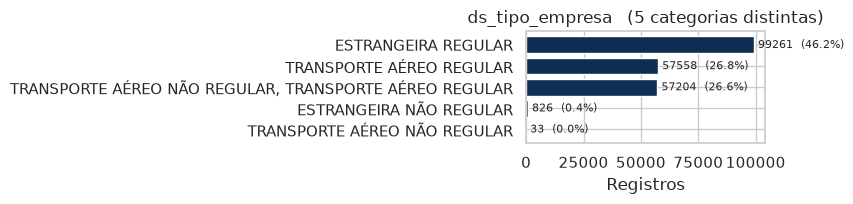

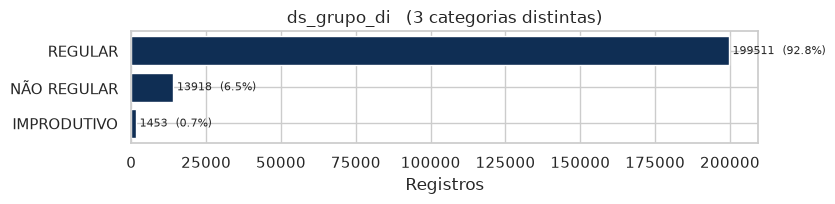

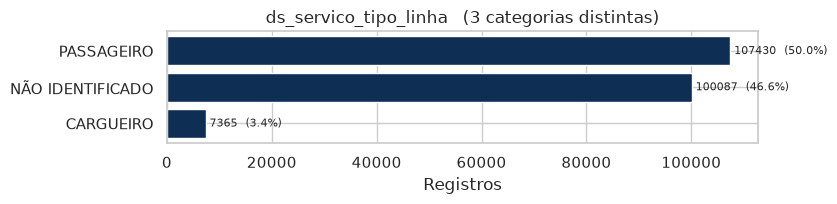

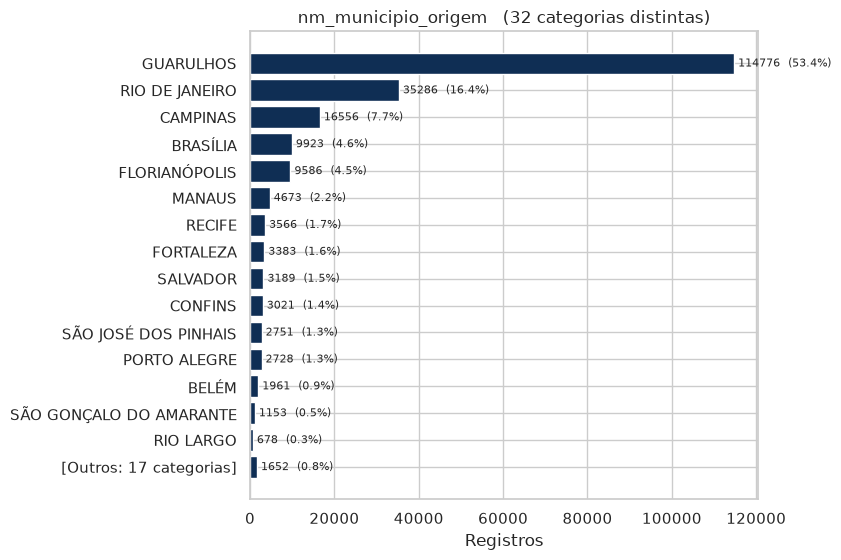

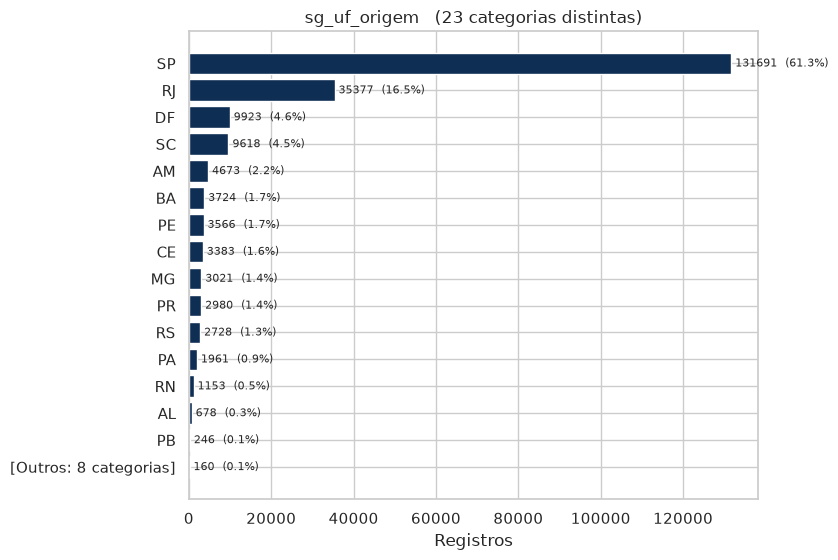

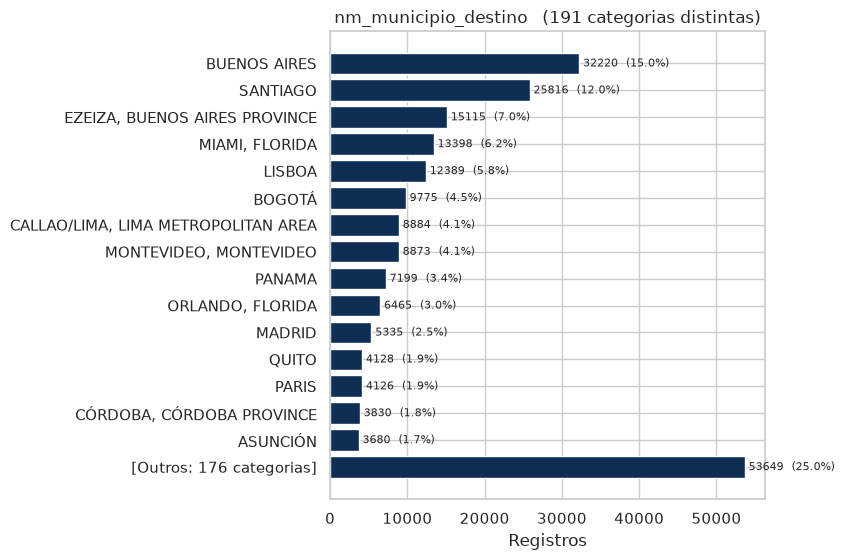

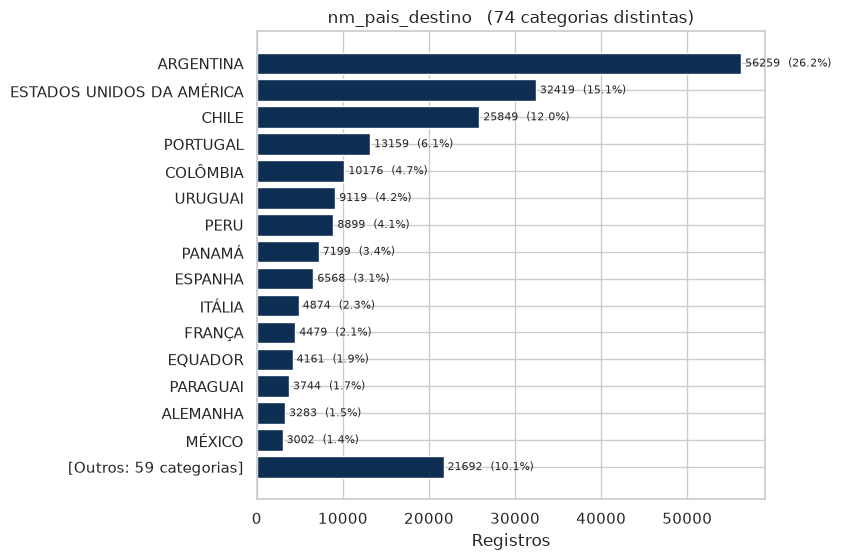

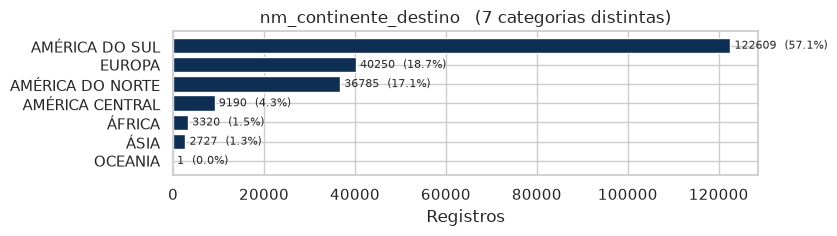

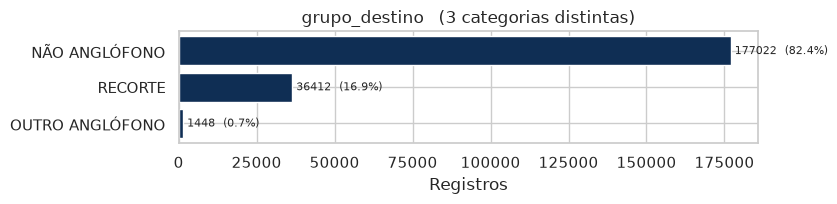

In [22]:
for c in COLS_CAT:
    vc = df[c].value_counts(dropna=False)
    if vc.empty:
        continue

    total_cat = df[c].nunique(dropna=True)
    if total_cat > MAX_CATEGORIAS:
        principais = vc.head(MAX_CATEGORIAS)
        outros = vc.iloc[MAX_CATEGORIAS:].sum()
        n_outros = len(vc) - MAX_CATEGORIAS
        principais = pd.concat([principais,
                                pd.Series({f"[Outros: {n_outros} categorias]": outros})])
    else:
        principais = vc

    fig, ax = plt.subplots(figsize=(8.5, max(2.2, 0.36 * len(principais))))
    ax.barh([str(i) for i in principais.index][::-1], principais.values[::-1],
            color="#0F2E54")
    ax.set_title(f"{c}   ({total_cat} categorias distintas)")
    ax.set_xlabel("Registros")
    for i, v in enumerate(principais.values[::-1]):
        ax.text(v, i, f" {v}  ({v/len(df)*100:.1f}%)", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

→ Categorias que aparecem escritas de formas diferentes (`SP`, `sp`, `São Paulo`) são o mesmo valor para o negócio e valores distintos para o Python. Se você vir isso aqui, volte à canonicalização da Aula 4 antes de prosseguir.

---
# 5) Outliers

In [23]:
def detecta_outliers(s):
    s = s.dropna()
    if len(s) < 4 or s.nunique() < 3:
        return None

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()

    dp = s.std()
    n_z = (abs(s - s.mean()) > 3 * dp).sum() if dp else 0

    mad = (s - s.median()).abs().median()
    n_zmod = (0.6745 * (s - s.median()).abs() / mad > 3.5).sum() if mad else 0

    return {
        "n": len(s),
        "lim_inf_iqr": round(lim_inf, 2),
        "lim_sup_iqr": round(lim_sup, 2),
        "outliers_iqr": n_iqr,
        "pct_iqr": round(n_iqr / len(s) * 100, 1),
        "outliers_z3": n_z,
        "outliers_zmod": n_zmod,
    }


linhas = []
for c in COLS_NUM:
    r = detecta_outliers(df[c])
    if r:
        linhas.append({"variavel": c, **r})

if linhas:
    display(pd.DataFrame(linhas).set_index("variavel"))
    print("Onde os três métodos discordam muito, a distribuição não é normal —")
    print("e o IQR costuma ser a leitura mais confiável.")
else:
    print("Nenhuma variável numérica com dados suficientes para detecção.")

,n,lim_inf_iqr,lim_sup_iqr,outliers_iqr,pct_iqr,outliers_z3,outliers_zmod
variavel,,,,,,,
nr_passag_pagos,214814,-255.0,425.0,309,0.1,332,0
nr_passag_gratis,214814,-1.5,2.5,36727,17.1,4898,0
kg_bagagem_livre,214814,-127.5,212.5,50244,23.4,7162,0
kg_carga_paga,214814,-1350.0,2250.0,44570,20.7,3257,0
kg_bagagem_excesso,214814,0.0,0.0,7775,3.6,1056,0
kg_carga_gratis,214814,0.0,0.0,8897,4.1,1009,0
kg_correio,214814,0.0,0.0,6157,2.9,1547,0


Onde os três métodos discordam muito, a distribuição não é normal —
e o IQR costuma ser a leitura mais confiável.


In [24]:
# As linhas extremas de cada variável, para inspeção manual
for c in COLS_NUM:
    s = df[c].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    fora = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    if len(fora):
        print(f"\n{'='*55}\n{c}: {len(fora)} candidatos a outlier\n{'='*55}")
        display(fora.nlargest(min(5, len(fora)), c).head())


nr_passag_pagos: 309 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
1610,93513522,UAE,262,2025-01-03 01:25:00,SBGR,OMDB,NaN,1,2,484.0,0.0,0.0,7678.0,0.0,0.0,0.0,EMIRATES,EMIRADOS ÁRABES UNIDOS,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,DUBAI INTERNATIONAL,EMIRADOS ÁRABES UNIDOS,ÁSIA,NÃO ANGLÓFONO
1612,93513524,UAE,262,2025-01-05 01:25:00,SBGR,OMDB,NaN,1,2,484.0,0.0,0.0,1905.0,0.0,0.0,0.0,EMIRATES,EMIRADOS ÁRABES UNIDOS,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,DUBAI INTERNATIONAL,EMIRADOS ÁRABES UNIDOS,ÁSIA,NÃO ANGLÓFONO
1617,93513529,UAE,262,2025-01-10 01:37:00,SBGR,OMDB,NaN,1,2,484.0,0.0,0.0,5000.0,0.0,0.0,0.0,EMIRATES,EMIRADOS ÁRABES UNIDOS,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,DUBAI INTERNATIONAL,EMIRADOS ÁRABES UNIDOS,ÁSIA,NÃO ANGLÓFONO
35795,95228805,UAE,262,2025-04-10 01:38:00,SBGR,OMDB,NaN,1,2,484.0,0.0,0.0,5303.0,0.0,0.0,0.0,EMIRATES,EMIRADOS ÁRABES UNIDOS,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,DUBAI INTERNATIONAL,EMIRADOS ÁRABES UNIDOS,ÁSIA,NÃO ANGLÓFONO
35799,95228804,UAE,262,2025-04-09 01:39:00,SBGR,OMDB,NaN,1,2,484.0,0.0,0.0,2811.0,0.0,0.0,0.0,EMIRATES,EMIRADOS ÁRABES UNIDOS,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,DUBAI INTERNATIONAL,EMIRADOS ÁRABES UNIDOS,ÁSIA,NÃO ANGLÓFONO



nr_passag_gratis: 36727 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
45521,95635669,DAL,268,2025-05-23 10:04:00,SBGR,KATL,NaN,1,2,9.0,260.0,0.0,9740.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTADOS UNIDOS DA AMÉRICA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,ATLANTA,ESTADOS UNIDOS DA AMÉRICA,AMÉRICA DO NORTE,RECORTE
136359,102279515,DAL,9906,2026-01-05 23:57:00,SBGL,KATL,NaN,1,2,122.0,157.0,0.0,0.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTADOS UNIDOS DA AMÉRICA,ESTRANGEIRA REGULAR,NÃO REGULAR,NÃO IDENTIFICADO,RIO DE JANEIRO,RJ,ATLANTA,ESTADOS UNIDOS DA AMÉRICA,AMÉRICA DO NORTE,RECORTE
143819,102921977,GLO,9460,2026-01-05 08:15:00,SBGR,TLPL,DESEMBARQUE,1,2,0.0,111.0,1390.0,0.0,0.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",NÃO REGULAR,PASSAGEIRO,GUARULHOS,SP,"VIEUX-FORT, SAINT LUCIA",SANTA LÚCIA,AMÉRICA CENTRAL,OUTRO ANGLÓFONO
2014,93636428,UAL,3032,2025-01-14 22:10:00,SBGR,KIAD,NaN,1,2,91.0,62.0,0.0,7768.0,0.0,0.0,0.0,"UNITED AIRLINES, INC",ESTADOS UNIDOS DA AMÉRICA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,"WASHINGTON, DC",ESTADOS UNIDOS DA AMÉRICA,AMÉRICA DO NORTE,RECORTE
34747,95480323,DAL,268,2025-04-01 10:00:00,SBGR,KATL,NaN,1,2,171.0,59.0,0.0,6662.0,0.0,0.0,0.0,DELTA AIR LINES INC.,ESTADOS UNIDOS DA AMÉRICA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,ATLANTA,ESTADOS UNIDOS DA AMÉRICA,AMÉRICA DO NORTE,RECORTE



kg_bagagem_livre: 50244 candidatos a outlier


...

,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
46113,96102518,GLO,7684,2025-05-01 14:09:00,SBGR,SABE,CONEXÃO INTERNACIONAL,1,2,13.0,0.0,146.0,0.0,1279.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,GUARULHOS,SP,BUENOS AIRES,ARGENTINA,AMÉRICA DO SUL,NÃO ANGLÓFONO
59152,97498850,GLO,7680,2025-06-13 17:55:00,SBGR,SABE,DESEMBARQUE,1,2,156.0,0.0,1158.0,0.0,926.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,GUARULHOS,SP,BUENOS AIRES,ARGENTINA,AMÉRICA DO SUL,NÃO ANGLÓFONO
42957,95360418,GLO,7044,2025-04-10 23:19:00,SBGR,SABE,DESEMBARQUE,1,2,135.0,1.0,969.0,0.0,887.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,GUARULHOS,SP,BUENOS AIRES,ARGENTINA,AMÉRICA DO SUL,NÃO ANGLÓFONO
71830,98147428,GLO,7714,2025-07-22 12:50:00,SBGR,SLVR,DESEMBARQUE,1,2,141.0,0.0,1973.0,0.0,828.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,GUARULHOS,SP,SANTA CRUZ,BOLÍVIA,AMÉRICA DO SUL,NÃO ANGLÓFONO
42936,95358339,GLO,7730,2025-04-09 15:53:00,SBGR,MDPC,DESEMBARQUE,1,2,150.0,8.0,1521.0,239.0,823.0,0.0,0.0,GOL LINHAS AÉREAS S.A. (EX- VRG LINHAS AÉREAS ...,BRASIL,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO...",REGULAR,PASSAGEIRO,GUARULHOS,SP,PUNTA CANA,REPÚBLICA DOMINICANA,AMÉRICA CENTRAL,NÃO ANGLÓFONO



kg_carga_gratis: 8897 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
152744,103696439,TAM,8202,2026-02-08 07:31:00,SBGR,SPJC,DESEMBARQUE,1,2,120.0,3.0,1666.0,997.0,0.0,43554.0,0.0,TAM LINHAS AÉREAS S.A.,BRASIL,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"CALLAO/LIMA, LIMA METROPOLITAN AREA",PERU,AMÉRICA DO SUL,NÃO ANGLÓFONO
116950,101092304,AFR,485,2025-11-13 21:14:00,SBGL,LFPG,NaN,1,2,338.0,0.0,0.0,252.0,0.0,18001.0,0.0,SOCIÉTÉ AIR FRANCE,FRANÇA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,RIO DE JANEIRO,RJ,PARIS,FRANÇA,EUROPA,NÃO ANGLÓFONO
150805,103405454,AFR,485,2026-02-27 20:49:00,SBGL,LFPG,NaN,1,2,358.0,5.0,0.0,250.0,0.0,15410.0,0.0,SOCIÉTÉ AIR FRANCE,FRANÇA,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,RIO DE JANEIRO,RJ,PARIS,FRANÇA,EUROPA,NÃO ANGLÓFONO
95748,99523766,TAM,8194,2025-09-22 11:14:00,SBGR,KMIA,DESEMBARQUE,1,2,238.0,5.0,2784.0,0.0,0.0,10979.0,0.0,TAM LINHAS AÉREAS S.A.,BRASIL,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"MIAMI, FLORIDA",ESTADOS UNIDOS DA AMÉRICA,AMÉRICA DO NORTE,RECORTE
71647,97626464,LNE,721,2025-07-13 13:58:00,SBKP,SEQM,NaN,1,2,0.0,0.0,0.0,0.0,0.0,9524.0,0.0,LATAM AIRLINES ECUADOR S.A.,EQUADOR,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,CAMPINAS,SP,QUITO,EQUADOR,AMÉRICA DO SUL,NÃO ANGLÓFONO



kg_correio: 6157 candidatos a outlier


,id_combinada,sg_empresa_icao,nr_voo,dh_partida_real,sg_icao_origem,sg_icao_destino,ds_cotran,nr_etapa,nr_escala_destino,nr_passag_pagos,nr_passag_gratis,kg_bagagem_livre,kg_carga_paga,kg_bagagem_excesso,kg_carga_gratis,kg_correio,nm_empresa,nm_pais_empresa,ds_tipo_empresa,ds_grupo_di,ds_servico_tipo_linha,nm_municipio_origem,sg_uf_origem,nm_municipio_destino,nm_pais_destino,nm_continente_destino,grupo_destino
30922,94906705,TAM,8202,2025-03-01 07:31:00,SBGR,SPJC,DESEMBARQUE,1,2,160.0,3.0,2111.0,6335.0,0.0,108.0,8079.0,TAM LINHAS AÉREAS S.A.,BRASIL,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,"CALLAO/LIMA, LIMA METROPOLITAN AREA",PERU,AMÉRICA DO SUL,NÃO ANGLÓFONO
127561,101796935,TAM,8076,2025-12-03 22:01:00,SBGR,LEMD,DESEMBARQUE,1,2,187.0,8.0,2603.0,7205.0,0.0,0.0,7776.0,TAM LINHAS AÉREAS S.A.,BRASIL,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO
120716,101240393,TAM,8058,2025-11-29 22:54:00,SBGR,FAOR,DESEMBARQUE,1,2,204.0,0.0,2564.0,1953.0,0.0,0.0,7075.0,TAM LINHAS AÉREAS S.A.,BRASIL,TRANSPORTE AÉREO REGULAR,REGULAR,PASSAGEIRO,GUARULHOS,SP,JOHANNESBURG,ÁFRICA DO SUL,ÁFRICA,OUTRO ANGLÓFONO
135407,102274794,LAN,715,2026-01-31 07:25:00,SBGR,SCEL,NaN,1,2,189.0,4.0,0.0,115.0,0.0,0.0,7071.0,LATAM AIRLINES GROUP (EX - LAN AIRLINES S/A),CHILE,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,SANTIAGO,CHILE,AMÉRICA DO SUL,NÃO ANGLÓFONO
171934,104920811,LAN,714,2026-04-04 00:49:00,SBGR,LEMD,NaN,3,4,271.0,0.0,0.0,3678.0,0.0,0.0,6697.0,LATAM AIRLINES GROUP (EX - LAN AIRLINES S/A),CHILE,ESTRANGEIRA REGULAR,REGULAR,NÃO IDENTIFICADO,GUARULHOS,SP,MADRID,ESPANHA,EUROPA,NÃO ANGLÓFONO


---
# 6) Séries temporais

Executa apenas se houver alguma coluna de data na base.

In [25]:
if COLS_DT:
    COL_TEMPO = COLS_DT[0]
    print(f"Coluna de tempo usada: {COL_TEMPO}")
    print(f"Período: {df[COL_TEMPO].min()}  ->  {df[COL_TEMPO].max()}")
    print(f"Registros sem data: {df[COL_TEMPO].isna().sum()}")

    tmp = df.dropna(subset=[COL_TEMPO]).set_index(COL_TEMPO).sort_index()
    dias = (tmp.index.max() - tmp.index.min()).days
    freq = "D" if dias <= 90 else ("W" if dias <= 730 else "MS")
    rotulo = {"D": "dia", "W": "semana", "MS": "mês"}[freq]
    print(f"Amplitude: {dias} dias -> agregando por {rotulo}")
else:
    print("Nenhuma coluna de data identificada. Seção 6 ignorada.")
    print("Se a sua base tem datas, informe-as em COLS_DATA na configuração.")

Coluna de tempo usada: dh_partida_real


Período: 2024-12-31 23:47:00  ->  2026-08-01 22:29:00
Registros sem data: 0


Amplitude: 577 dias -> agregando por semana


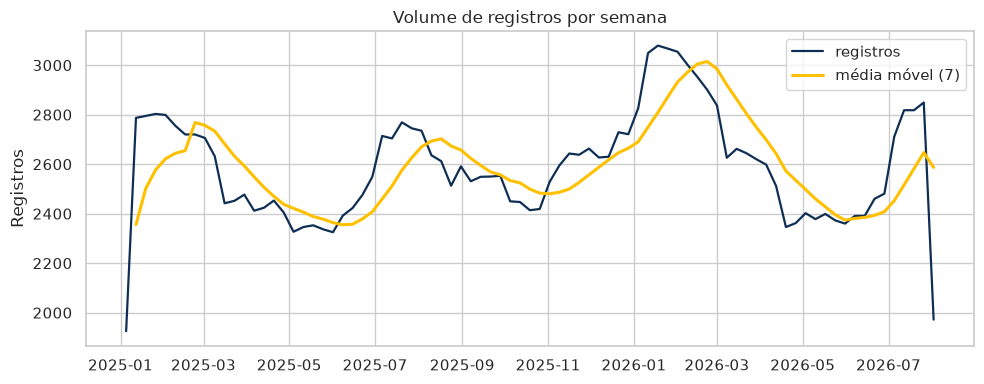

Procure: degraus (troca de sistema), buracos (falha de carga)
e o último período, que costuma estar incompleto.


In [26]:
if COLS_DT:
    volume = tmp.resample(freq).size()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(volume.index, volume.values, lw=1.6, color="#0F2E54", label="registros")
    if len(volume) >= 5:
        jan = max(3, min(7, len(volume) // 3))
        ax.plot(volume.index, volume.rolling(jan, min_periods=2).mean(),
                lw=2.2, color="#FFC000", label=f"média móvel ({jan})")
    ax.set_title(f"Volume de registros por {rotulo}")
    ax.set_ylabel("Registros")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Procure: degraus (troca de sistema), buracos (falha de carga)")
    print("e o último período, que costuma estar incompleto.")

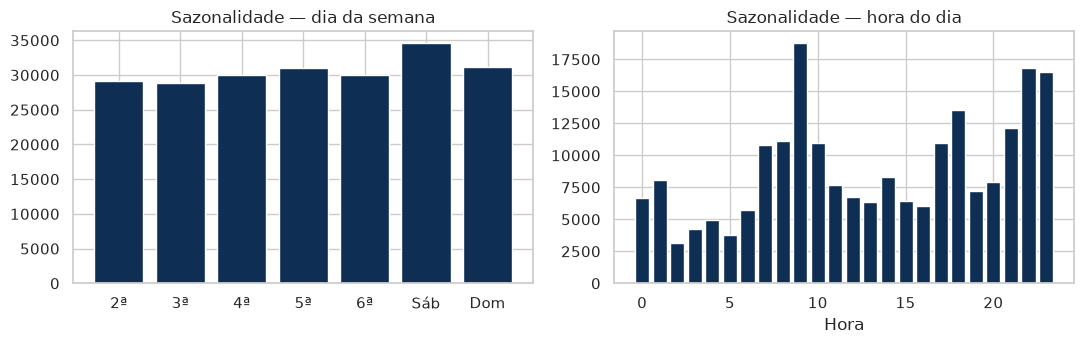

In [27]:
if COLS_DT:
    dias_pt = {"Monday": "2ª", "Tuesday": "3ª", "Wednesday": "4ª", "Thursday": "5ª",
               "Friday": "6ª", "Saturday": "Sáb", "Sunday": "Dom"}
    ordem = ["2ª", "3ª", "4ª", "5ª", "6ª", "Sáb", "Dom"]

    d = df.dropna(subset=[COL_TEMPO]).copy()
    d["_dia"] = d[COL_TEMPO].dt.day_name().map(dias_pt)
    d["_hora"] = d[COL_TEMPO].dt.hour

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    por_dia = d["_dia"].value_counts().reindex(ordem).fillna(0)
    axes[0].bar(por_dia.index, por_dia.values, color="#0F2E54")
    axes[0].set_title("Sazonalidade — dia da semana")

    if d["_hora"].nunique() > 1:
        por_hora = d["_hora"].value_counts().sort_index()
        axes[1].bar(por_hora.index, por_hora.values, color="#0F2E54")
        axes[1].set_title("Sazonalidade — hora do dia")
        axes[1].set_xlabel("Hora")
    else:
        axes[1].text(0.5, 0.5, "Sem informação de hora",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## 6.1) [Grupo 4] Do registro ao voo

A pergunta de negócio é sobre voos e passageiros, não sobre linhas da ANAC. A célula abaixo monta a tabela `df_voo`, com uma linha por voo, usada nas seções 6.2, 10.1 e 10.2.

In [28]:
# [Grupo 4] Da linha da ANAC para o voo
# Uma linha é um par de aeroportos dentro de um voo, desdobrado por ds_cotran.
# Para contar voos, as linhas são somadas ao voo: empresa, número e data de partida.
# O destino do voo é o da linha com mais passageiros. As repetições de grão
# (mesmo voo declarado em dois arquivos mensais) saem antes da soma.
base = df.drop_duplicates(subset=GRAO).copy()
base["pax"] = base["nr_passag_pagos"].fillna(0) + base["nr_passag_gratis"].fillna(0)
base["data_partida"] = base["dh_partida_real"].dt.normalize()
CHAVE_VOO = ["sg_empresa_icao", "nr_voo", "data_partida"]

df_voo = (base.sort_values("pax", ascending=False)
              .groupby(CHAVE_VOO, as_index=False)
              .agg(pax=("pax", "sum"),
                   linhas=("pax", "size"),
                   grupo_destino=("grupo_destino", "first"),
                   nm_pais_destino=("nm_pais_destino", "first"),
                   nm_continente_destino=("nm_continente_destino", "first"),
                   ds_servico_tipo_linha=("ds_servico_tipo_linha", "first"),
                   ds_tipo_empresa=("ds_tipo_empresa", "first")))
df_voo["mes"] = df_voo["data_partida"].dt.to_period("M")
df_voo["passageiros"] = (df_voo["ds_servico_tipo_linha"] != "CARGUEIRO") & (df_voo["pax"] > 0)

print(f"Linhas da base: {len(df):,}   voos distintos: {len(df_voo):,}".replace(",", "."))
print(f"Linhas por voo: média {len(base) / len(df_voo):.2f}")
display(df_voo["linhas"].value_counts().sort_index().rename("voos").to_frame().T)
print(f"Voos de passageiros: {df_voo['passageiros'].sum():,}".replace(",", "."))
print(f"Voos de carga ou sem passageiro: {(~df_voo['passageiros']).sum():,}".replace(",", "."))

Linhas da base: 214.882   voos distintos: 130.513
Linhas por voo: média 1.65


linhas,1,2,3,4,5,6,8,9,12,18
voos,89252,6619,32104,417,2,1728,106,100,175,10


Voos de passageiros: 120.410
Voos de carga ou sem passageiro: 10.103


## 6.2) [Grupo 4] Série mensal de passageiros

Somente voos de passageiros, nos 19 meses completos (jan/2025 a jul/2026). Os voos de 31/12/2024 e de 01/08/2026, que caíram nos arquivos vizinhos, ficam fora.

grupo_destino,NÃO ANGLÓFONO,OUTRO ANGLÓFONO,RECORTE,% recorte
2025-01,1032005,8079,293732,22.0
2025-02,945928,6209,226642,19.2
2025-03,965509,6595,262291,21.2
2025-04,886994,6591,233847,20.7
2025-05,867577,6804,224271,20.4
2025-06,872509,7410,226962,20.5
2025-07,1050399,8560,237276,18.3
2025-08,1019325,7526,231106,18.4
2025-09,956946,8174,213411,18.1
2025-10,931496,8156,227340,19.5


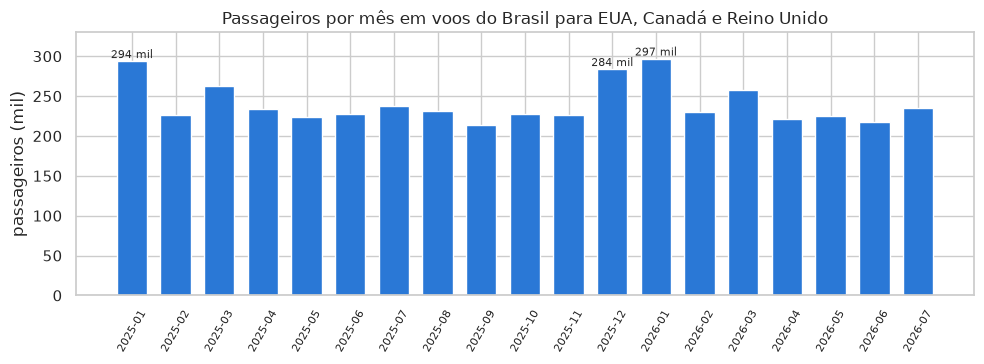

,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
voos,1186.0,1029.0,1107.0,903.0,916.0,906.0,952.0,900.0,839.0,889.0,923.0,1102.0,1143.0,961.0,1005.0,827.0,876.0,877.0,948.0
pax,293732.0,226642.0,262291.0,233847.0,224271.0,226962.0,237276.0,231106.0,213411.0,227340.0,225808.0,283720.0,296851.0,230242.0,257136.0,221316.0,224790.0,217090.0,235391.0
pax_por_voo,247.7,220.3,236.9,259.0,244.8,250.5,249.2,256.8,254.4,255.7,244.6,257.5,259.7,239.6,255.9,267.6,256.6,247.5,248.3


In [29]:
# [Grupo 4] Passageiros por mês: recorte x demais destinos
MESES = pd.period_range("2025-01", "2026-07", freq="M")   # meses completos
pv = df_voo[df_voo["passageiros"] & df_voo["mes"].isin(MESES)]

mensal = pv.pivot_table(index="mes", columns="grupo_destino", values="pax",
                        aggfunc="sum").reindex(MESES)
mensal["% recorte"] = (mensal["RECORTE"] / mensal[["RECORTE", "NÃO ANGLÓFONO", "OUTRO ANGLÓFONO"]].sum(axis=1) * 100).round(1)
display(mensal.astype({"RECORTE": int, "NÃO ANGLÓFONO": int, "OUTRO ANGLÓFONO": int}))

rec = pv[pv["grupo_destino"] == "RECORTE"].groupby("mes").agg(voos=("pax", "size"), pax=("pax", "sum")).reindex(MESES)
rec["pax_por_voo"] = (rec["pax"] / rec["voos"]).round(1)

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(MESES))
ax.bar(x, rec["pax"] / 1000, color="#2a78d6", width=0.7)
for i in [0, 11, 12]:
    ax.text(i, rec["pax"].iloc[i] / 1000 + 4, f"{rec['pax'].iloc[i] / 1000:.0f} mil", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in MESES], rotation=60, fontsize=8)
ax.set_ylabel("passageiros (mil)")
ax.set_ylim(0, 330)
ax.set_title("Passageiros por mês em voos do Brasil para EUA, Canadá e Reino Unido")
plt.tight_layout()
plt.show()
display(rec.T)

,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
passageiros,124.0,95.7,110.7,98.7,94.7,95.8,100.2,97.6,90.1,96.0,95.3,119.8,129.0,100.1,111.8,96.2,97.7,94.4,102.3
voos,123.8,107.4,115.6,94.3,95.6,94.6,99.4,93.9,87.6,92.8,96.3,115.0,127.5,107.2,112.1,92.3,97.7,97.9,105.8
passageiros por voo,100.0,88.9,95.6,104.5,98.8,101.1,100.6,103.6,102.7,103.2,98.7,103.9,101.1,93.3,99.6,104.2,99.9,96.3,96.7


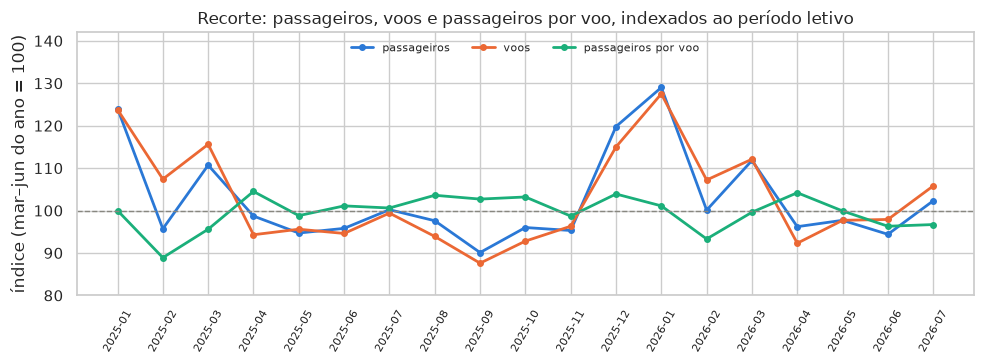

In [30]:
# [Grupo 4] O pico vem de mais voos ou de voos mais cheios?
# Índice = mês / média de março a junho do mesmo ano (período letivo, sem Carnaval)
def indice_letivo(serie):
    out = serie.copy().astype(float)
    for ano in (2025, 2026):
        base_ano = serie[[pd.Period(f"{ano}-{m:02d}", "M") for m in (3, 4, 5, 6)]].mean()
        meses_ano = [p for p in serie.index if p.year == ano]
        out[meses_ano] = serie[meses_ano] / base_ano * 100
    return out

decomp = pd.DataFrame({"passageiros": indice_letivo(rec["pax"]),
                       "voos": indice_letivo(rec["voos"]),
                       "passageiros por voo": indice_letivo(rec["pax_por_voo"])}).round(1)
display(decomp.T)

fig, ax = plt.subplots(figsize=(10, 3.8))
for col, cor in [("passageiros", "#2a78d6"), ("voos", "#eb6834"), ("passageiros por voo", "#1baf7a")]:
    ax.plot(x, decomp[col], lw=2, color=cor, marker="o", ms=4, label=col)
ax.axhline(100, color="#888780", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in MESES], rotation=60, fontsize=8)
ax.set_ylabel("índice (mar–jun do ano = 100)")
ax.set_title("Recorte: passageiros, voos e passageiros por voo, indexados ao período letivo")
ax.set_ylim(80, 142)
ax.legend(fontsize=8, loc="upper center", ncol=3, frameon=False)
plt.tight_layout()
plt.show()

---
# 7) Bivariada

Para cada par relevante, o gráfico correspondente ao par de tipos.

Pares numéricos com maior associação (Spearman, em módulo):


spearman_abs
nr_passag_pagos  nr_passag_gratis         0.582
                 kg_carga_paga            0.439
nr_passag_gratis kg_carga_paga            0.384

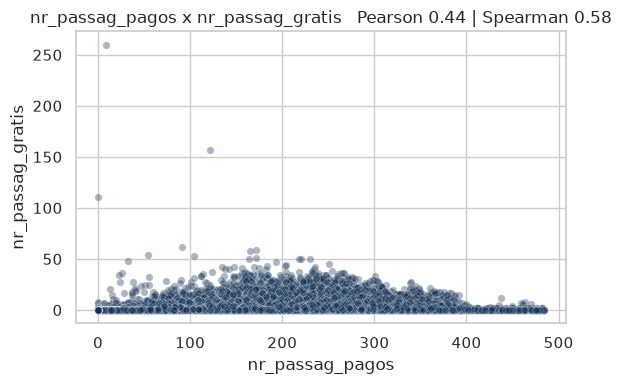

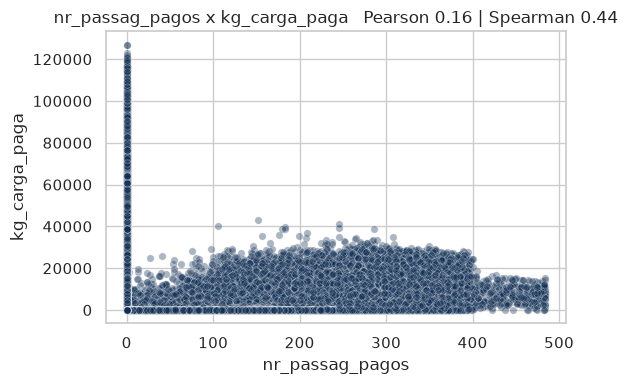

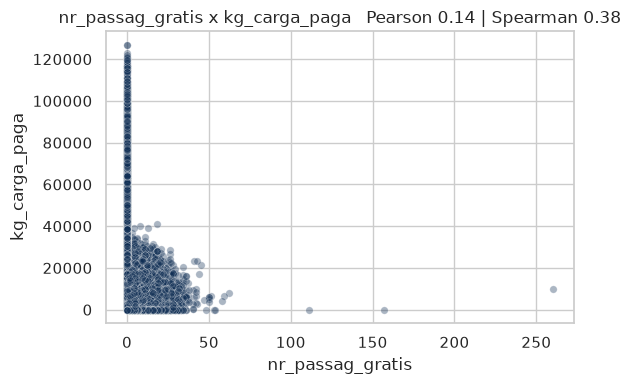

In [31]:
# Numérica x Numérica — dispersão dos pares mais correlacionados
if len(COLS_NUM) >= 2:
    corr_s = df[COLS_NUM].corr(method="spearman").abs()
    pares = (corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False))
    top = pares.head(3)

    print("Pares numéricos com maior associação (Spearman, em módulo):")
    display(top.round(3).to_frame("spearman_abs"))

    for (a, b), _ in top.items():
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(data=df, x=a, y=b, alpha=0.35, s=28,
                        color="#0F2E54", ax=ax)
        p = df[[a, b]].corr().iloc[0, 1]
        sp = df[[a, b]].corr(method="spearman").iloc[0, 1]
        ax.set_title(f"{a} x {b}   Pearson {p:.2f} | Spearman {sp:.2f}")
        plt.tight_layout()
        plt.show()
else:
    print("Menos de duas variáveis numéricas — dispersão não se aplica.")

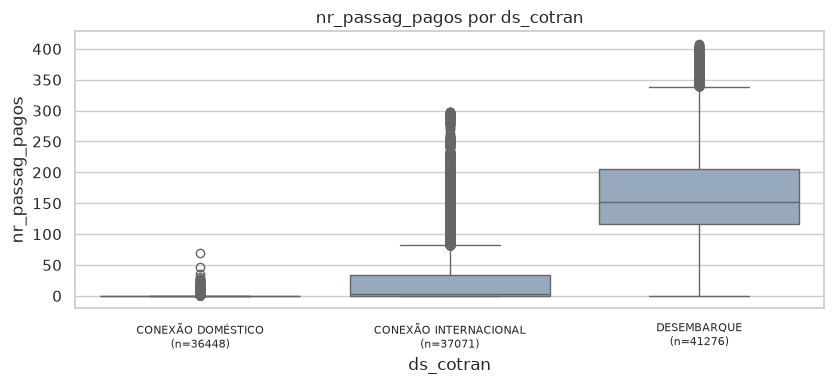

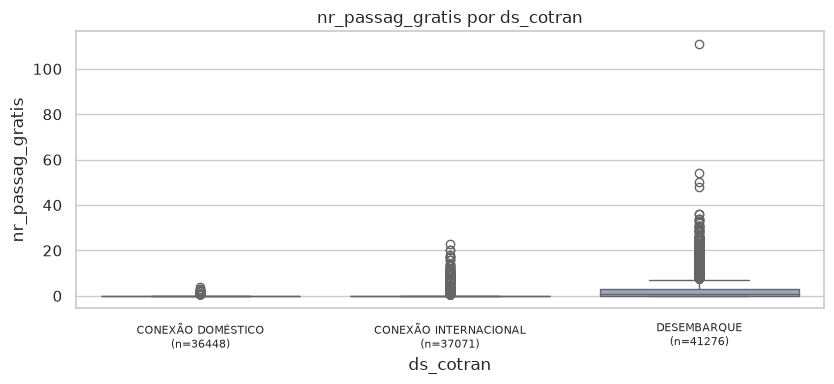

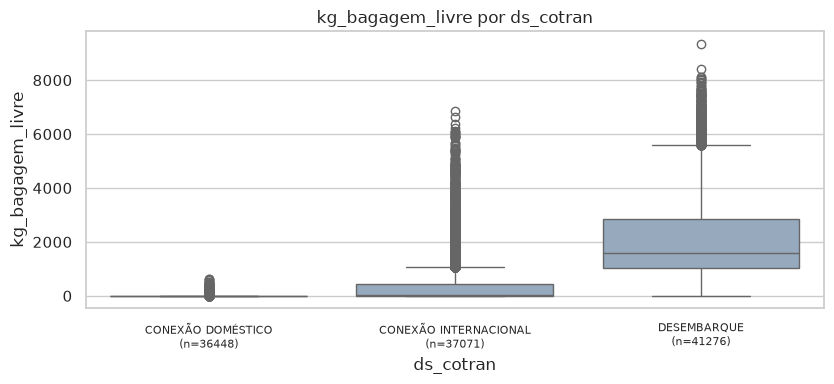

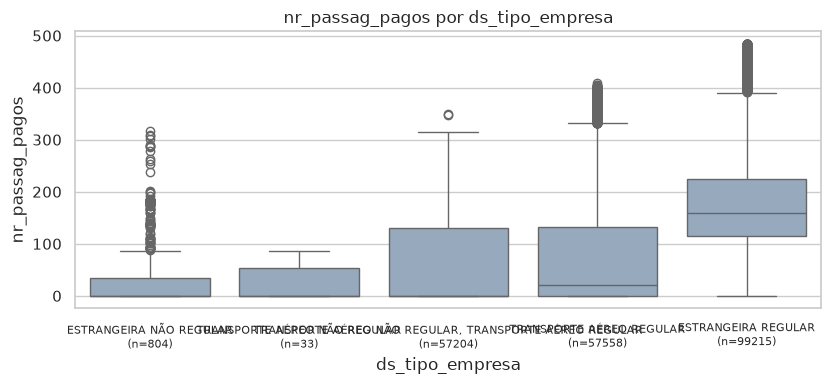

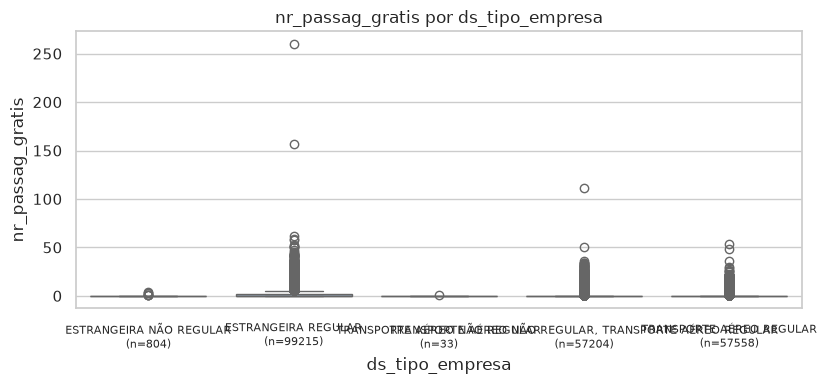

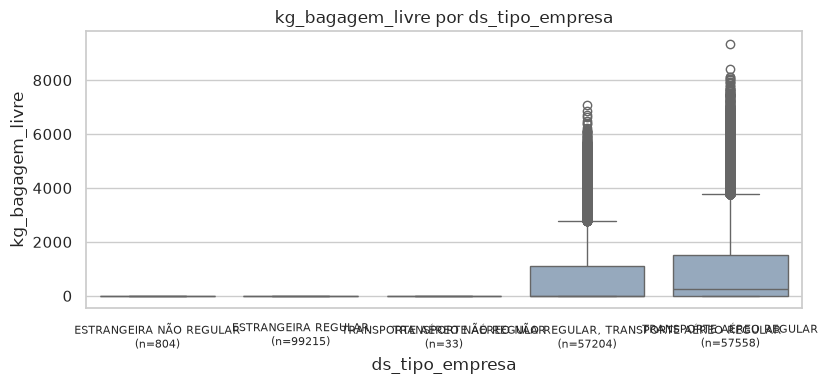

In [32]:
# Categórica x Numérica — boxplot por categoria
pares_feitos = 0
for cat in COLS_CAT:
    if not (2 <= df[cat].nunique() <= 12):
        continue
    for num in COLS_NUM[:3]:
        fig, ax = plt.subplots(figsize=(8.5, 4))
        ordem_cat = df.groupby(cat)[num].median().sort_values().index
        sns.boxplot(data=df, x=cat, y=num, order=ordem_cat,
                    color="#8FA9C4", ax=ax)
        ns = df.groupby(cat)[num].count().reindex(ordem_cat)
        ax.set_xticklabels([f"{c}\n(n={ns[c]})" for c in ordem_cat], fontsize=8)
        ax.set_title(f"{num} por {cat}")
        plt.tight_layout()
        plt.show()
        pares_feitos += 1
        if pares_feitos >= 6:
            break
    if pares_feitos >= 6:
        break

if pares_feitos == 0:
    print("Nenhum par categórica x numérica adequado encontrado.")

Contagem — ds_cotran x ds_tipo_empresa


ds_tipo_empresa,TRANSPORTE AÉREO NÃO REGULAR,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,,
CONEXÃO DOMÉSTICO,11,17251,19186
CONEXÃO INTERNACIONAL,11,17874,19186
DESEMBARQUE,11,22079,19186



Proporção por linha (o que se deve ler)


ds_tipo_empresa,TRANSPORTE AÉREO NÃO REGULAR,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,,
CONEXÃO DOMÉSTICO,0.0,47.3,52.6
CONEXÃO INTERNACIONAL,0.0,48.2,51.8
DESEMBARQUE,0.0,53.5,46.5


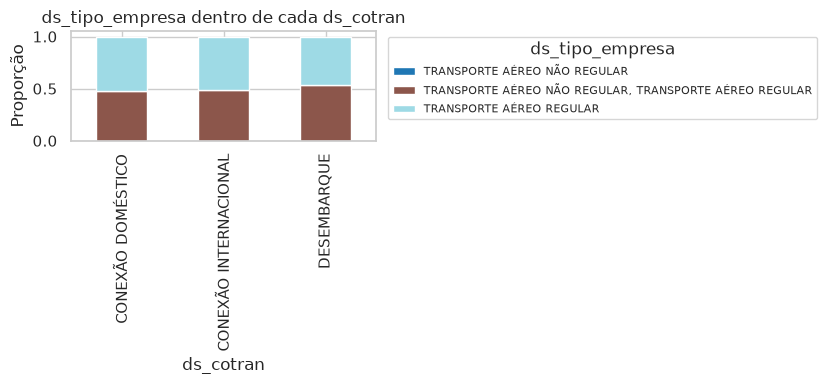

In [33]:
# Categórica x Categórica — proporção por linha, nunca contagem
cats_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 10]

if len(cats_ok) >= 2:
    a, b = cats_ok[0], cats_ok[1]
    ct_n = pd.crosstab(df[a], df[b])
    ct_p = pd.crosstab(df[a], df[b], normalize="index")

    print(f"Contagem — {a} x {b}")
    display(ct_n)
    print(f"\nProporção por linha (o que se deve ler)")
    display((ct_p * 100).round(1))

    fig, ax = plt.subplots(figsize=(8.5, 4))
    ct_p.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_ylabel("Proporção")
    ax.set_title(f"{b} dentro de cada {a}")
    ax.legend(title=b, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Menos de duas categóricas adequadas para tabela de contingência.")

---
# 8) Correlação

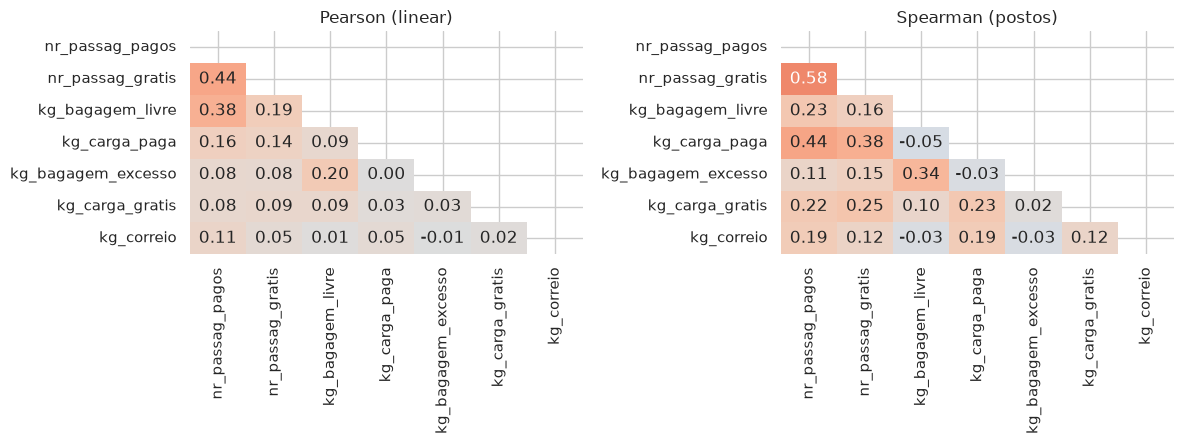

Pares em que Pearson e Spearman discordam (diferença > 0,15):


,,diferenca
nr_passag_pagos,kg_carga_paga,0.280
nr_passag_gratis,kg_carga_paga,0.245
kg_carga_paga,kg_carga_gratis,0.195
nr_passag_gratis,kg_carga_gratis,0.158


Relação provavelmente não linear, ou influenciada por outliers.
Olhe o gráfico de dispersão antes de concluir qualquer coisa.


In [ ]:
if len(COLS_NUM) >= 2:
    p = df[COLS_NUM].corr(method="pearson")
    s = df[COLS_NUM].corr(method="spearman")
    mask = np.triu(np.ones_like(p, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    sns.heatmap(p, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title("Pearson (linear)")
    sns.heatmap(s, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[1], cbar=False)
    axes[1].set_title("Spearman (postos)")
    plt.tight_layout()
    plt.show()

    dif = (s - p).abs()
    dif = dif.where(np.triu(np.ones(dif.shape), k=1).astype(bool)).stack()
    fortes = dif[dif > 0.15].sort_values(ascending=False)
    if len(fortes):
        print("Pares em que Pearson e Spearman discordam (diferença > 0,15):")
        display(fortes.round(3).to_frame("diferenca"))
        print("Relação provavelmente não linear, ou influenciada por outliers.")
    else:
        print("Pearson e Spearman concordam em todos os pares.")
else:
    print("Menos de duas variáveis numéricas.")

> **Lembrete de Anscombe:** nenhum número desta matriz entra no relatório sem o gráfico de dispersão correspondente ao lado.

---
# 9) Segmentação

A métrica principal por cada dimensão categórica

In [35]:
ALVO = COL_ALVO if COL_ALVO in df.columns else (COLS_NUM[0] if COLS_NUM else None)

if ALVO is None:
    print("Nenhuma variável-alvo disponível. Defina COL_ALVO na configuração.")
elif ALVO in COLS_NUM:
    print(f"Variável analisada: {ALVO} (numérica)\n")
    for cat in COLS_CAT:
        if not (2 <= df[cat].nunique() <= 20):
            continue
        seg = (df.groupby(cat)[ALVO]
                 .agg(n="size", media="mean", mediana="median", desvio="std")
                 .round(2)
                 .sort_values("media", ascending=False))
        seg["confiavel"] = np.where(seg["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} ---")
        display(seg)
else:
    print(f"Variável analisada: {ALVO} (categórica)\n")
    for cat in COLS_CAT:
        if cat == ALVO or not (2 <= df[cat].nunique() <= 20):
            continue
        ct = pd.crosstab(df[cat], df[ALVO], normalize="index").round(3) * 100
        ct["n"] = df[cat].value_counts()
        ct["confiavel"] = np.where(ct["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} (% por linha) ---")
        display(ct)

Variável analisada: nr_passag_pagos (numérica)

--- nr_passag_pagos por ds_cotran ---


,n,media,mediana,desvio,confiavel
ds_cotran,,,,,
DESEMBARQUE,41276,159.13,152.0,84.39,sim
CONEXÃO INTERNACIONAL,37071,22.03,3.0,36.93,sim
CONEXÃO DOMÉSTICO,36448,0.11,0.0,1.02,sim


--- nr_passag_pagos por ds_tipo_empresa ---


,n,media,mediana,desvio,confiavel
ds_tipo_empresa,,,,,
ESTRANGEIRA REGULAR,99261,158.98,160.0,94.18,sim
TRANSPORTE AÉREO REGULAR,57558,74.01,21.0,98.43,sim
"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",57204,54.69,0.0,79.74,sim
ESTRANGEIRA NÃO REGULAR,826,31.39,0.0,61.41,sim
TRANSPORTE AÉREO NÃO REGULAR,33,20.12,0.0,29.46,sim


--- nr_passag_pagos por ds_grupo_di ---


...

,n,media,mediana,desvio,confiavel
ds_servico_tipo_linha,,,,,
NÃO IDENTIFICADO,100087,157.95,159.0,94.65,sim
PASSAGEIRO,107430,68.78,7.0,91.51,sim
CARGUEIRO,7365,0.00,0.0,0.00,sim


--- nr_passag_pagos por nm_continente_destino ---


,n,media,mediana,desvio,confiavel
nm_continente_destino,,,,,
ÁSIA,2727,236.14,255.0,134.35,sim
EUROPA,40250,179.13,229.0,126.57,sim
AMÉRICA CENTRAL,9190,133.53,155.0,51.83,sim
AMÉRICA DO NORTE,36785,115.23,88.0,112.13,sim
ÁFRICA,3320,114.84,124.0,100.94,sim
AMÉRICA DO SUL,122609,77.42,73.0,76.14,sim
OCEANIA,1,16.00,16.0,NaN,N BAIXO


--- nr_passag_pagos por grupo_destino ---


,n,media,mediana,desvio,confiavel
grupo_destino,,,,,
RECORTE,36412,121.83,103.0,116.18,sim
OUTRO ANGLÓFONO,1448,106.29,83.0,90.19,sim
NÃO ANGLÓFONO,177022,105.09,115.0,100.43,sim


→ Segmentos marcados como **N BAIXO** têm poucos registros: a métrica deles oscila muito por construção

---
# 10) Multivariada

Facetas e o teste de Simpson.

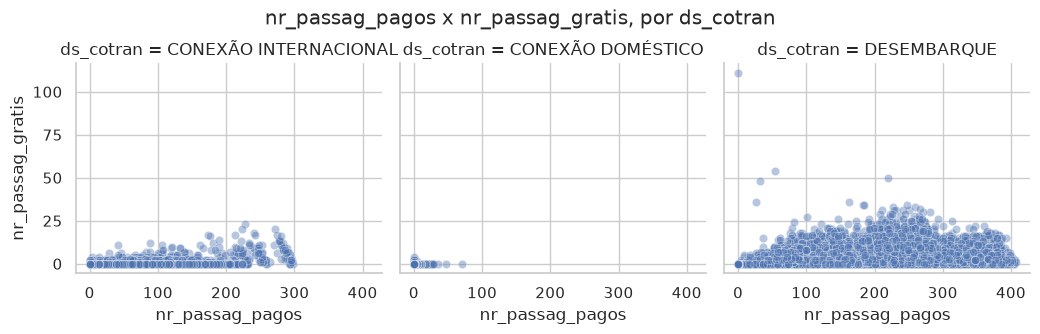

Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.


In [ ]:
# Facetas: a mesma relação, repetida dentro de cada valor de uma terceira variável
cats_faceta = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 4]

if cats_faceta and len(COLS_NUM) >= 2:
    faceta = cats_faceta[0]
    x, y = COLS_NUM[0], COLS_NUM[1]
    g = sns.relplot(data=df, x=x, y=y, col=faceta, kind="scatter",
                    alpha=0.4, height=3.2, aspect=1.1,
                    facet_kws={"sharex": True, "sharey": True})
    g.figure.suptitle(f"{x} x {y}, por {faceta}", y=1.04)
    plt.show()
    print("Eixos fixos em todos os painéis, tornando os painéis comparáveis.")
else:
    print("Sem combinação adequada para facetas.")

In [ ]:
def teste_simpson(df, grupo, segmento, metrica):
    """Compara a direção da métrica no agregado e dentro de cada segmento."""
    agregado = df.groupby(grupo)[metrica].mean()
    vencedor_geral = agregado.idxmax()

    por_seg = df.groupby([segmento, grupo])[metrica].mean().unstack()
    por_seg = por_seg.dropna()
    if por_seg.empty:
        return None

    vencedores = por_seg.idxmax(axis=1)
    invertidos = vencedores[vencedores != vencedor_geral]

    margem = round(float(agregado.max() - agregado.min()), 4)

    return {
        "margem_agregado": margem,
        "agregado": agregado.round(3),
        "por_segmento": por_seg.round(3),
        "composicao": pd.crosstab(df[grupo], df[segmento], normalize="index").round(3),
        "vencedor_geral": vencedor_geral,
        "segmentos_invertidos": list(invertidos.index),
    }


grupos_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 5]

# Se o alvo for categórico binário, vira uma métrica 0/1 — bem mais informativo
df_s = df.copy()
metrica = None
if COL_ALVO in df.columns and df[COL_ALVO].nunique(dropna=True) == 2:
    niveis = sorted(df[COL_ALVO].dropna().unique())
    df_s["_taxa_alvo"] = (df_s[COL_ALVO] == niveis[-1]).astype(float)
    metrica = "_taxa_alvo"
    print(f"Métrica: proporção de '{niveis[-1]}' em {COL_ALVO}")
elif COLS_NUM:
    metrica = COLS_NUM[0]
    print(f"Métrica: {metrica}")

grupos_ok = [c for c in grupos_ok if c != COL_ALVO]

if len(grupos_ok) >= 2 and metrica:
    grupo, segmento = grupos_ok[0], grupos_ok[1]
    df = df_s
    print(f"Grupos: {grupo}   |   Segmentado por: {segmento}\n")

    r = teste_simpson(df, grupo, segmento, metrica)
    if r:
        print("No agregado:")
        display(r["agregado"])
        print("\nPor segmento:")
        display(r["por_segmento"])
        print("\nComposição de cada grupo:")
        display(r["composicao"])

        if r["segmentos_invertidos"]:
            print("\n" + "!" * 60)
            print(f"ATENÇÃO: no agregado vence '{r['vencedor_geral']}',")
            print(f"mas em {r['segmentos_invertidos']} o vencedor é outro.")
            print(f"Margem no agregado: {r['margem_agregado']}")
            print("Isto é o paradoxo de Simpson.")
            print("!" * 60)
        else:
            print("\nDireção consistente entre agregado e segmentos, sem inversão.")
else:
    print("Combinação insuficiente para o teste de Simpson.")
    print("Ele exige duas categóricas de poucos níveis e uma métrica numérica.")

Métrica: nr_passag_pagos
Grupos: ds_cotran   |   Segmentado por: ds_tipo_empresa



No agregado:


ds_cotran
CONEXÃO DOMÉSTICO          0.105
CONEXÃO INTERNACIONAL     22.030
DESEMBARQUE              159.128
Name: nr_passag_pagos, dtype: float64


Por segmento:


ds_cotran,CONEXÃO DOMÉSTICO,CONEXÃO INTERNACIONAL,DESEMBARQUE
ds_tipo_empresa,,,
TRANSPORTE AÉREO NÃO REGULAR,0.000,40.455,19.909
"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",0.204,7.761,135.244
TRANSPORTE AÉREO REGULAR,0.016,35.313,186.692



Composição de cada grupo (é aqui que o paradoxo nasce):


ds_tipo_empresa,TRANSPORTE AÉREO NÃO REGULAR,"TRANSPORTE AÉREO NÃO REGULAR, TRANSPORTE AÉREO REGULAR",TRANSPORTE AÉREO REGULAR
ds_cotran,,,
CONEXÃO DOMÉSTICO,0.0,0.473,0.526
CONEXÃO INTERNACIONAL,0.0,0.482,0.518
DESEMBARQUE,0.0,0.535,0.465



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ATENÇÃO: no agregado vence 'DESEMBARQUE',
mas em ['TRANSPORTE AÉREO NÃO REGULAR'] o vencedor é outro.
Margem no agregado: 159.0225
Verifique se a diferença é grande o bastante para importar.
Isto é o paradoxo de Simpson. NÃO reporte apenas o agregado.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


→ O teste acima roda no primeiro par de categóricas encontrado. **Rode-o manualmente** para as combinações que fazem sentido no seu domínio — é o conhecimento do negócio que aponta onde procurar confundimento, não o código.

```python
r = teste_simpson(df, grupo="unidade", segmento="faixa_etaria", metrica="faltou")
```

## 10.1) [Grupo 4] Relação controlada por uma terceira variável

Relação analisada: **mês do ano → passageiros**. A terceira variável é o **grupo de destino**: se o pico das férias for o mesmo para os destinos de língua inglesa e para os demais, ele é efeito das férias em geral, e não um sinal específico do recorte. Em seguida, os destinos não anglófonos são abertos por continente.

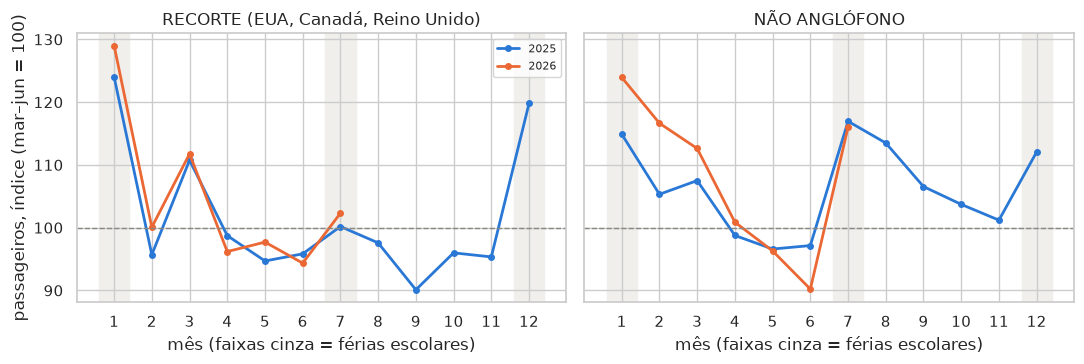

,RECORTE,NÃO ANGLÓFONO
jan/2025 sobre mar–jun,124.0,114.9
jan/2026 sobre mar–jun,129.0,123.9
dez/2025 sobre mar–jun,119.8,112.1
jul/2025 sobre jun/2025 (%),4.5,20.4
jul/2026 sobre jun/2026 (%),8.4,28.6


In [38]:
# [Grupo 4] A sazonalidade sobrevive ao controle pelo grupo de destino?
# Mesma relação (mês do ano -> passageiros), repetida dentro de cada grupo de destino.
GRUPOS = ["RECORTE", "NÃO ANGLÓFONO"]
idx_grupo = {g: indice_letivo(mensal[g]) for g in GRUPOS}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, g in zip(axes, GRUPOS):
    s = idx_grupo[g]
    for ano, cor in [(2025, "#2a78d6"), (2026, "#eb6834")]:
        pts = s[[p for p in s.index if p.year == ano]]
        ax.plot([p.month for p in pts.index], pts.values, lw=2, color=cor, marker="o", ms=4, label=str(ano))
    ax.axhline(100, color="#888780", lw=1, ls="--")
    for m in (1, 7, 12):
        ax.axvspan(m - 0.4, m + 0.4, color="#f0efec", zorder=0)
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("mês (faixas cinza = férias escolares)")
    ax.set_title(g if g != "RECORTE" else "RECORTE (EUA, Canadá, Reino Unido)")
axes[0].set_ylabel("passageiros, índice (mar–jun = 100)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

def razao(s, a, b):
    return s[pd.Period(a, "M")] / s[pd.Period(b, "M")]

resumo = pd.DataFrame({g: {
    "jan/2025 sobre mar–jun": round(idx_grupo[g][pd.Period("2025-01", "M")], 1),
    "jan/2026 sobre mar–jun": round(idx_grupo[g][pd.Period("2026-01", "M")], 1),
    "dez/2025 sobre mar–jun": round(idx_grupo[g][pd.Period("2025-12", "M")], 1),
    "jul/2025 sobre jun/2025 (%)": round((razao(mensal[g], "2025-07", "2025-06") - 1) * 100, 1),
    "jul/2026 sobre jun/2026 (%)": round((razao(mensal[g], "2026-07", "2026-06") - 1) * 100, 1),
} for g in GRUPOS})
display(resumo)

m                                     pax jun    pax jul  jul sobre jun (%)
grupo_destino nm_continente_destino                                        
NÃO ANGLÓFONO AMÉRICA DO SUL         801319.0  1169623.0               46.0
              AMÉRICA DO NORTE        25688.0    33140.0               29.0
              AMÉRICA CENTRAL        129406.0   150137.0               16.0
              ÁSIA                    61725.0    69877.0               13.2
RECORTE       AMÉRICA DO NORTE       391687.0   423117.0                8.0
NÃO ANGLÓFONO EUROPA                 702242.0   726721.0                3.5
RECORTE       EUROPA                  52365.0    49550.0               -5.4
NÃO ANGLÓFONO ÁFRICA                  23435.0    21398.0               -8.7

Países que mais contribuem para o aumento de julho (não anglófonos):


m,6,7,acréscimo jul-jun,% do acréscimo total
nm_pais_destino,,,,
CHILE,240440.0,424795.0,184355.0,43.2
ARGENTINA,303320.0,436646.0,133326.0,31.2
URUGUAI,46642.0,66128.0,19486.0,4.6
PORTUGAL,237635.0,253138.0,15503.0,3.6
PANAMÁ,115413.0,129326.0,13913.0,3.3
COLÔMBIA,85635.0,98945.0,13310.0,3.1


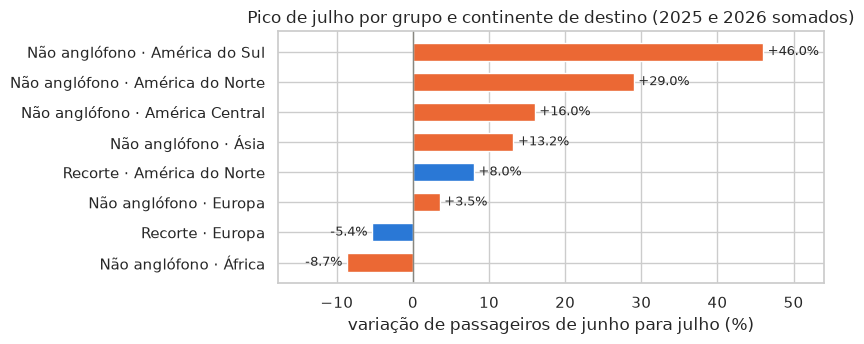

In [39]:
# [Grupo 4] Dentro dos destinos não anglófonos: de onde vem o pico de julho?
# Controle pelo continente de destino (meses de junho e julho dos dois anos somados)
jj = pv[pv["mes"].dt.month.isin([6, 7])]
cont = (jj.assign(m=jj["mes"].dt.month)
          .pivot_table(index=["grupo_destino", "nm_continente_destino"], columns="m", values="pax", aggfunc="sum"))
cont = cont[cont[6] >= 20000]
cont["jul sobre jun (%)"] = ((cont[7] / cont[6] - 1) * 100).round(1)
display(cont.rename(columns={6: "pax jun", 7: "pax jul"}).sort_values("jul sobre jun (%)", ascending=False))

pais = (jj[jj["grupo_destino"] == "NÃO ANGLÓFONO"].assign(m=jj["mes"].dt.month)
          .pivot_table(index="nm_pais_destino", columns="m", values="pax", aggfunc="sum"))
pais["acréscimo jul-jun"] = pais[7] - pais[6]
top = pais.sort_values("acréscimo jul-jun", ascending=False).head(6)
top["% do acréscimo total"] = (top["acréscimo jul-jun"] / pais["acréscimo jul-jun"].sum() * 100).round(1)
print("Países que mais contribuem para o aumento de julho (não anglófonos):")
display(top)

NOME_CONT = {"AMÉRICA DO SUL": "América do Sul", "AMÉRICA DO NORTE": "América do Norte",
             "AMÉRICA CENTRAL": "América Central", "EUROPA": "Europa", "ÁSIA": "Ásia", "ÁFRICA": "África"}
plot = cont["jul sobre jun (%)"].sort_values()
cores = ["#2a78d6" if i[0] == "RECORTE" else "#eb6834" for i in plot.index]
rotulos = [("Recorte · " if i[0] == "RECORTE" else "Não anglófono · ") + NOME_CONT[i[1]] for i in plot.index]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(rotulos, plot.values, color=cores, height=0.6)
for i, v in enumerate(plot.values):
    ax.text(v + (0.6 if v >= 0 else -0.6), i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.axvline(0, color="#888780", lw=1)
ax.set_xlim(plot.min() - 9, plot.max() + 8)
ax.set_xlabel("variação de passageiros de junho para julho (%)")
ax.set_title("Pico de julho por grupo e continente de destino (2025 e 2026 somados)")
plt.tight_layout()
plt.show()

## 10.2) [Grupo 4] Teste de Simpson na combinação escolhida pelo grupo

O teste automático acima escolheu `ds_cotran` × `ds_tipo_empresa`, uma combinação sem sentido de negócio (a "inversão" aparece num segmento de 33 linhas). A combinação do grupo responde a uma pergunta do domínio: **nas férias escolares os voos saem mais cheios, e isso vale dentro de cada grupo de destino?**

In [40]:
# [Grupo 4] Teste de Simpson escolhido pelo grupo
# Pergunta: nas férias escolares os voos saem mais cheios?
# Grupo = período (férias: jan, jul, dez); métrica = passageiros por voo;
# segmento = grupo de destino. Base: voos de passageiros de 2025 (um ano civil
# completo, para que cada mês pese uma vez só).
v25 = df_voo[df_voo["passageiros"] & (df_voo["mes"].dt.year == 2025)].copy()
v25["periodo"] = np.where(v25["mes"].dt.month.isin([1, 7, 12]), "férias", "fora das férias")

r = teste_simpson(v25, grupo="periodo", segmento="grupo_destino", metrica="pax")
display(r["agregado"], r["por_segmento"], r["composicao"])
print("Invertidos:", r["segmentos_invertidos"])

periodo
fora das férias    194.198
férias             192.322
Name: pax, dtype: float64

periodo,fora das férias,férias
grupo_destino,,
NÃO ANGLÓFONO,184.397,180.869
OUTRO ANGLÓFONO,213.824,226.569
RECORTE,246.277,251.459


grupo_destino,NÃO ANGLÓFONO,OUTRO ANGLÓFONO,RECORTE
periodo,,,
fora das férias,0.839,0.006,0.156
férias,0.836,0.006,0.159


Invertidos: ['OUTRO ANGLÓFONO', 'RECORTE']


In [41]:
# [Grupo 4] A diferença é maior que o ruído? Intervalo de 95% por bootstrap
rng = np.random.default_rng(42)

def ic_diferenca(dados, n_boot=2000):
    a = dados.loc[dados["periodo"] == "férias", "pax"].to_numpy()
    b = dados.loc[dados["periodo"] == "fora das férias", "pax"].to_numpy()
    difs = [rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(difs, [2.5, 97.5])
    return a.mean() - b.mean(), lo, hi, len(a), len(b)

linhas = []
for nome, dados in [("AGREGADO", v25)] + [(g, v25[v25["grupo_destino"] == g]) for g in ["RECORTE", "NÃO ANGLÓFONO", "OUTRO ANGLÓFONO"]]:
    d, lo, hi, na, nb = ic_diferenca(dados)
    linhas.append([nome, na, nb, round(d, 1), round(lo, 1), round(hi, 1),
                   "não" if lo <= 0 <= hi else "sim"])
ic = pd.DataFrame(linhas, columns=["segmento", "voos férias", "voos fora", "diferença (pax/voo)",
                                   "IC95 inf", "IC95 sup", "diferente de zero?"]).set_index("segmento")
display(ic)

,voos férias,voos fora,diferença (pax/voo),IC95 inf,IC95 sup,diferente de zero?
segmento,,,,,,
AGREGADO,20434,54030,-1.9,-3.2,-0.5,sim
RECORTE,3240,8412,5.2,2.1,8.6,sim
NÃO ANGLÓFONO,17078,45311,-3.5,-5.0,-2.1,sim
OUTRO ANGLÓFONO,116,307,12.7,0.3,25.3,sim


In [42]:
# [Grupo 4] Mesmo teste, segmentando pelo continente de destino
r2 = teste_simpson(v25[v25["nm_continente_destino"] != "OCEANIA"], grupo="periodo",
                   segmento="nm_continente_destino", metrica="pax")
display(r2["por_segmento"])
print("Invertidos:", r2["segmentos_invertidos"])

periodo,fora das férias,férias
nm_continente_destino,,
AMÉRICA CENTRAL,145.022,156.218
AMÉRICA DO NORTE,237.375,244.076
AMÉRICA DO SUL,147.820,146.165
EUROPA,279.995,275.329
ÁFRICA,193.036,199.728
ÁSIA,286.294,285.799


Invertidos: ['AMÉRICA CENTRAL', 'AMÉRICA DO NORTE', 'ÁFRICA']


In [43]:
# [Grupo 4] Verificação num recorte que não foi usado para achar o resultado
# O teste acima usou 2025. Repetimos em jan–jul/2026 (férias = jan e jul).
v26 = df_voo[df_voo["passageiros"] & (df_voo["mes"] >= pd.Period("2026-01", "M"))
             & (df_voo["mes"] <= pd.Period("2026-07", "M"))].copy()
v26["periodo"] = np.where(v26["mes"].dt.month.isin([1, 7]), "férias", "fora das férias")

linhas = []
for nome, dados in [("AGREGADO", v26)] + [(g, v26[v26["grupo_destino"] == g]) for g in ["RECORTE", "NÃO ANGLÓFONO"]]:
    d, lo, hi, na, nb = ic_diferenca(dados)
    linhas.append([nome, na, nb, round(d, 1), round(lo, 1), round(hi, 1)])
display(pd.DataFrame(linhas, columns=["segmento", "voos férias", "voos fora", "diferença (pax/voo)",
                                      "IC95 inf", "IC95 sup"]).set_index("segmento"))

,voos férias,voos fora,diferença (pax/voo),IC95 inf,IC95 sup
segmento,,,,,
AGREGADO,14883,31050,-6.2,-7.8,-4.6
RECORTE,2091,4546,1.4,-3.2,5.9
NÃO ANGLÓFONO,12702,26316,-7.2,-8.8,-5.6


---
# 11) Síntese

A EDA não termina em gráficos. Termina em **achados, hipóteses e decisões**.

Preencha a célula abaixo com as suas conclusões — é este texto, e não os gráficos, que vai para o relatório do PI.

In [44]:
SINTESE = """
Base: voos com origem no Brasil e destino no exterior, ANAC (etapas combinadas),
jan/2025 a jul/2026. Recorte do projeto: EUA, Canadá e Reino Unido. Os demais
destinos são o grupo de comparação. Índice sazonal = mês / média de mar–jun do
mesmo ano (= 100).

ACHADOS PROCURADOS DE PROPÓSITO
   1. O recorte responde por 19,1% dos passageiros pagos internacionais (4,4 de
      23,2 milhões). Dentro dele, EUA 83,2%, Reino Unido 11,1%, Canadá 5,7%.
      Sustentação: seção 9 e tabela da seção 6.2.

   2. O pico do recorte é dezembro e janeiro, não julho. Índice de jan/2025 = 124,
      dez/2025 = 120, jan/2026 = 129. Julho sobe só 4,5% (2025) e 8,4% (2026) sobre
      junho. Sustentação: gráficos das seções 6.2 e 10.1.

   3. Controlando pelo grupo de destino, o efeito "férias de julho" não sobrevive
      no recorte. Nos destinos não anglófonos julho sobe 20,4% e 28,6% sobre junho;
      no recorte, 4,5% e 8,4%. O pico de dez/jan aparece nos dois grupos, mais forte
      no recorte (124 e 129 contra 115 e 124). Sustentação: facetas da seção 10.1.

   4. O pico de janeiro do recorte vem de mais voos, não de voos mais cheios: voos
      com índice 124 e 128, passageiros por voo com 100 e 101. Sustentação: gráfico
      indexado da seção 6.2.

   5. Simpson (período x grupo de destino, passageiros por voo, voos de 2025): no
      agregado, voo de férias leva 1,9 passageiro a menos (IC95% -3,2 a -0,5). No
      recorte leva 5,2 a mais (IC95% 2,1 a 8,6); nos não anglófonos, 3,5 a menos.
      Inversão parcial (2 de 3 segmentos). A composição quase não muda (recorte é
      15,6% dos voos fora das férias e 15,9% nas férias): não é paradoxo por
      composição, é efeito com sinais opostos que o agregado esconde, porque os não
      anglófonos são 84% dos voos. Verificação em jan–jul/2026, que não foi usado
      no teste: os não anglófonos repetem (-7,2), mas o recorte fica em +1,4 com
      IC95% de -3,2 a 5,9. A inversão no recorte não se confirma: fica como
      hipótese. Sustentação: seção 10.2.

ACHADOS ENCONTRADOS POR ACASO (relatados como hipótese)
   6. ds_cotran falta em 100% das linhas de empresas estrangeiras e em 0% das
      brasileiras. O mesmo conjunto (100.087 linhas) é o NÃO IDENTIFICADO de
      ds_servico_tipo_linha. A taxa mensal fica entre 43% e 51%. Seção 2.4.

   7. Seis voos aparecem duas vezes, todos na virada do mês (dia 1º ou 31/12);
      em 5 deles as duas cópias divergem em ds_grupo_di. Seção 2.3.

   8. Chile (43,2%) e Argentina (31,2%) explicam 74% do aumento de julho nos
      destinos não anglófonos; a América do Sul sobe 46%. Seção 10.1.

   9. O recorte tem um pico secundário em março nos dois anos (índice 111 e 112),
      também puxado por voos. Seção 6.2.

  10. nr_passag_pagos tem três modas: zero (31,4% das linhas; 97% das linhas de
      conexão doméstica), cerca de 150 e cerca de 270. As 309 linhas acima do
      limite do IQR (425) são Emirates (302) e Air France (7). Seções 3 e 5.

HIPÓTESES
   1. Dez/jan do recorte é férias de fim de ano e viagem de compras e lazer aos
      EUA. Verificar com motivo da viagem (Embratur, Polícia Federal) e, para o
      projeto, com a data de cadastro dos alunos do cliente, testando defasagens
      de 1 a 6 meses.
   2. Julho dos não anglófonos é turismo de inverno na América do Sul (neve no
      Chile e na Argentina). Verificar abrindo por cidade (Santiago, Bariloche,
      Mendoza) e com mais anos.
   3. Março do recorte vem de aumento de oferta das companhias. Verificar com a
      malha programada (HOTRAN) e com anos anteriores.
   4. A ausência de ds_cotran é estrutural: estrangeiras declaram em formato que
      não detalha o tipo de movimento. Verificar no dicionário da ANAC.
   5. As 68 linhas sem medida são declarações incompletas de estrangeiras ainda
      não revisadas (26 delas em mai–jul/2026). Verificar baixando os mesmos meses
      de novo após a revisão da ANAC.
   6. As duplicatas vêm de voos na fronteira entre dois arquivos mensais.
      Verificar com nr_ano_mes_referencia, que existe na base bruta.
   7. Nas férias, o recorte enche aviões de oferta fixa (widebody), enquanto os
      não anglófonos ganham frequências extras e o passageiro por voo cai. A
      parte do recorte não se repetiu em 2026. Verificar com assentos ofertados
      (base de etapas básicas da ANAC) e com mais anos.

DECISÕES DE TRATAMENTO
   1. Ausentes. ds_cotran nulo não é imputado: vira "NÃO DETALHADO" e qualquer
      análise por tipo de movimento usa só empresas brasileiras. NÃO IDENTIFICADO
      fica como categoria (não entra em NA_EXTRA). As 68 linhas sem medida (0,03%)
      saem, com o motivo registrado. Das 6 duplicatas, fica uma cópia.
   2. Outliers. kg_carga_gratis negativo (3 linhas, Azul) é erro e vira nulo.
      nr_passag_gratis = 260 com 9 pagos (Delta) fica, e as métricas de grátis
      são reportadas com e sem ele. Os 484 pagos da Emirates são um A380:
      subpopulação legítima. Os zeros de passageiros (cargueiros, conexão
      doméstica, improdutivos) são subpopulações: a unidade de análise passa a
      ser o voo e os cargueiros saem da métrica de demanda. Nas variáveis kg_ com
      IQR = 0 a regra do IQR não se aplica.
   3. Categorias raras. OUTRO ANGLÓFONO (1.448 linhas, 0,7% dos passageiros)
      fica separado, fora do recorte e fora do controle. OCEANIA (1 linha) vai
      para "Outros". Os tipos de empresa raros (33 e 826 linhas) são agrupados em
      brasileira/estrangeira. IMPRODUTIVO sai da demanda. Os meses residuais
      2024-12 e 2026-08 saem das séries.

LIMITAÇÕES
   1. A base mede voos, não pessoas: não tem nacionalidade (estrangeiro voltando
      para casa conta como saída), motivo da viagem nem destino final. Irlanda,
      Austrália e Nova Zelândia não aparecem, porque se chega a elas por conexão.
   2. Não há dado de demanda por aulas de inglês. A pergunta central do projeto
      (a matrícula antecede a viagem?) depende da base do cliente.
   3. 19 meses dão um ciclo anual completo: janeiro a julho têm duas observações,
      agosto a dezembro uma. Não dá para separar tendência de sazonalidade.
   4. Variáveis de confusão fora da base: câmbio, preço da passagem, política de
      vistos e assentos ofertados (sem eles não há taxa de ocupação).
   5. Em 68,1% dos passageiros pagos (empresas estrangeiras) não se separa quem
      desembarca de quem segue em conexão.
"""

print(SINTESE)


Base: voos com origem no Brasil e destino no exterior, ANAC (etapas combinadas),
jan/2025 a jul/2026. Recorte do projeto: EUA, Canadá e Reino Unido. Os demais
destinos são o grupo de comparação. Índice sazonal = mês / média de mar–jun do
mesmo ano (= 100).

ACHADOS PROCURADOS DE PROPÓSITO
   1. O recorte responde por 19,1% dos passageiros pagos internacionais (4,4 de
      23,2 milhões). Dentro dele, EUA 83,2%, Reino Unido 11,1%, Canadá 5,7%.
      Sustentação: seção 9 e tabela da seção 6.2.

   2. O pico do recorte é dezembro e janeiro, não julho. Índice de jan/2025 = 124,
      dez/2025 = 120, jan/2026 = 129. Julho sobe só 4,5% (2025) e 8,4% (2026) sobre
      junho. Sustentação: gráficos das seções 6.2 e 10.1.

   3. Controlando pelo grupo de destino, o efeito "férias de julho" não sobrevive
      no recorte. Nos destinos não anglófonos julho sobe 20,4% e 28,6% sobre junho;
      no recorte, 4,5% e 8,4%. O pico de dez/jan aparece nos dois grupos, mais forte
      no recorte (124 e 

In [45]:
# Exportação da base tratada e do relatório de qualidade
df.to_csv("base_tratada.csv", index=False, encoding="utf-8-sig")
qualidade.to_csv("relatorio_qualidade.csv", encoding="utf-8-sig")

if COLS_NUM:
    desc.to_csv("estatistica_descritiva.csv", encoding="utf-8-sig")

print("Arquivos gerados:")
print("   base_tratada.csv")
print("   relatorio_qualidade.csv")
if COLS_NUM:
    print("   estatistica_descritiva.csv")

Arquivos gerados:
   base_tratada.csv
   relatorio_qualidade.csv
   estatistica_descritiva.csv


---

## Antes de entregar

- [ ] A configuração aponta para a base do seu PI, não para a base de exemplo
- [ ] A coluna `perda_pct` foi conferida: nenhuma conversão perdeu dados em silêncio
- [ ] Os nulos disfarçados encontrados foram acrescentados a `NA_EXTRA` e o notebook foi rodado de novo
- [ ] Cada candidato a outlier foi classificado: erro, evento raro ou subpopulação
- [ ] O teste de Simpson foi rodado nas combinações que fazem sentido no seu domínio
- [ ] A célula de síntese está preenchida

---

*SPTech School — Análise de Dados — Prof. Rodrigo Fernandes*